# 05: Demand estimation for Brooklyn

**Objective.** Estimate the spatial and temporal distribution of completed trip requests used by the
Brooklyn policy experiments. The demand model specifies an hourly arrival rate for each day type, origin
decision zone, and destination decision zone.

**Scope.** The notebook:

1. defines the completed trips included in demand estimation;
2. uses a 04:00 boundary to assign late night observations to demand day types;
3. evaluates exclusions for the June heat event and Independence Day period;
4. compares demand profiles across weekdays and months;
5. constructs the demand model for 20 decision zones and four day types;
6. examines the Poisson arrival assumption and variation across dates;
7. measures geographic imbalance and sensitivity to the decision zone count;
8. quantifies sampling uncertainty and fleet load under alternative capture shares; and
9. evaluates the fitted model against August 2025.

**Data.** New York City Taxi and Limousine Commission High Volume For Hire Vehicle trip records for
June and July 2025. Request time defines the arrival time. The working sample includes completed trips
with pickup and dropoff locations in Brooklyn. Shared and wheelchair accessible requests are retained.

**Latent demand.** The records contain fulfilled trips only. Requests that were not served, including
requests abandoned before a trip was recorded, are unavailable. The fitted volume is therefore an
observed completed trip rate. Demand uncensoring could be considered in a later extension if suitable
supply, wait time, cancellation, or application activity data become available.

**Evaluation timing.** The 04:00 boundary is used only to construct 24 hour demand profiles. It
does not constrain when an evaluation period begins.

**Calibration and evaluation.** The calibration window contains June and July 2025. Partial demand
periods at the window boundaries, June 23 through 25, and July 4 through 6 are excluded from the demand
fit. August 2025 is reserved for temporal evaluation and does not inform fitting decisions in this
notebook.

**Spatial units and output.** The model uses the 20 contiguous decision zones defined in Notebook 04.
Four day types, 20 origins, 20 destinations, and 24 hours produce 38,400 cells. Each cell stores its
completed trip count, number of contributing dates, and estimated hourly rate. A separately declared
capture share scales these rates for an experimental scenario; it is not an estimate of market share or
latent demand.

In [1]:
import duckdb, pandas as pd, numpy as np, geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from scipy import stats

from common import session, CALIBRATION_MONTHS, TEST_MONTH, RAW
import zoning
import vizstyle

vizstyle.apply()
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 160)
SEED = 20260902

con = session()          # duckdb views over CALIBRATION_MONTHS: raw, t (working set), z (taxi zones)
DOW = {0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"}
print(f"duckdb {duckdb.__version__} · calibration window {' + '.join(CALIBRATION_MONTHS)} · "
      f"test month {TEST_MONTH} · seed {SEED}")

duckdb 1.5.5 · calibration window 2025-06 + 2025-07 · test month 2025-08 · seed 20260902


## 1. Definition of observed demand

The TLC records describe completed trips. The demand model treats each record as one observed request
and uses `request_datetime` as its arrival time. Pickup time is excluded because it reflects the
realized dispatch and wait after the request was submitted.

The analysis applies the following inclusion rules:

* Pickup and dropoff must both be in Brooklyn. The modeled service network and travel time matrix contain
  Brooklyn locations only.
* Shared ride requests are retained, whether or not a shared match occurred.
* Wheelchair accessible requests, wheelchair accessible matches, and Access A Ride records are
  retained. The demand model does not distinguish service classes.

A wheelchair accessible match is not evidence that the rider requested an accessible vehicle. The
request and match fields are therefore reported separately below.

The records contain no observations for requests that were canceled or never served. Throughout this
notebook, demand refers to observed requests associated with completed trips.

### Inclusion rule

The fitted sample contains completed trips with both endpoints in Brooklyn. Shared, wheelchair
accessible, and Access A Ride flags do not affect inclusion. These records enter the model as standard
requests because the demand artifact has no service class dimension.

**Columns of the table below.** Counts of completed trips picked up in Brooklyn during June and July
2025.

| Column | Meaning |
|---|---|
| `group` | Trip subset |
| `n` | Number of completed trips |
| `pct` | Percentage of all completed trips picked up in Brooklyn |

In [2]:
bk_ids = [int(v) for v in con.sql("SELECT LocationID FROM z WHERE Borough = 'Brooklyn'").df().LocationID]
ids = ",".join(str(i) for i in bk_ids)

def build_pu(c):
    """Create the Brooklyn pickup view used for calibration and the August evaluation."""
    c.execute(f"""
CREATE OR REPLACE VIEW pu AS
SELECT PULocationID AS o, DOLocationID AS d,
       request_datetime AS rq, pickup_datetime AS pk, dropoff_datetime AS dr,
       trip_miles, trip_time,
       shared_request_flag = 'Y' AS shared_requested,
       shared_match_flag   = 'Y' AS shared_matched,
       wav_request_flag    = 'Y' AS wav_requested,
       wav_match_flag      = 'Y' AS wav_matched,
       access_a_ride_flag  = 'Y' AS access_a_ride,
       DOLocationID IN ({ids}) AS stays_in_brooklyn
FROM t
WHERE PULocationID IN ({ids})
""")


build_pu(con)

groups = con.sql("""
SELECT * FROM (
  SELECT 'picked up in Brooklyn' AS "group", count(*) AS n FROM pu
  UNION ALL SELECT 'dropped off in Brooklyn', count(*) FROM pu WHERE stays_in_brooklyn
  UNION ALL SELECT 'dropped off outside Brooklyn', count(*) FROM pu WHERE NOT stays_in_brooklyn
  UNION ALL SELECT 'shared: requested', count(*) FROM pu WHERE shared_requested
  UNION ALL SELECT 'shared: matched', count(*) FROM pu WHERE shared_matched
  UNION ALL SELECT 'wheelchair-accessible: requested', count(*) FROM pu WHERE wav_requested
  UNION ALL SELECT 'wheelchair-accessible: matched', count(*) FROM pu WHERE wav_matched
  UNION ALL SELECT 'Access-A-Ride (paratransit)', count(*) FROM pu WHERE access_a_ride
)
""").df()
groups["pct"] = (100 * groups.n / groups.n.iloc[0]).round(2)
groups

,group,n,pct
0,picked up in Brooklyn,10658762,100.00
1,dropped off in Brooklyn,8033670,75.37
2,dropped off outside Brooklyn,2625092,24.63
3,shared: requested,397522,3.73
4,shared: matched,259785,2.44
5,wheelchair-accessible: requested,36454,0.34
6,wheelchair-accessible: matched,1128871,10.59
7,Access-A-Ride (paratransit),12653,0.12


---

### Summary

The two month sample contains **10,658,762 completed trips** with pickups in Brooklyn. Of these,
**8,033,670**, or **75.37 percent**, also end in Brooklyn and meet the geographic inclusion rule.
The remaining **2,625,092**, or **24.63 percent**, end outside the borough.

Shared rides were requested for 3.73 percent of trips and matched for 2.44 percent. Wheelchair
accessible service was requested for 0.34 percent of trips, while the accessible match field is
positive for 10.59 percent. The difference confirms that the match field should not be used to measure
accessible service demand. Access A Ride accounts for 0.12 percent of Brooklyn pickups.

The demand model retains all service flags and does not model separate vehicle or service classes.
This has little effect on aggregate trip volume, but it prevents analysis of service outcomes for
riders who require an accessible vehicle.

**Columns of the table below.** Destinations of completed trips picked up in Brooklyn.

| Column | Meaning |
|---|---|
| `borough` | Borough of the dropoff zone. `N/A` and `Unknown` are TLC labels for unresolved zones |
| `n` | Number of completed trips |
| `pct` | Percentage of all completed trips picked up in Brooklyn |
| `mean_min` | Mean time from pickup to dropoff, in minutes |
| `mean_mi` | Mean reported trip distance, in miles |

In [3]:
con.sql("""
SELECT z.Borough AS borough, count(*) AS n,
       round(100.0 * count(*) / (SELECT count(*) FROM pu), 2) AS pct,
       round(avg(trip_time) / 60, 1) AS mean_min,
       round(avg(trip_miles), 2) AS mean_mi
FROM pu JOIN z ON pu.d = z.LocationID
GROUP BY 1 ORDER BY n DESC
""").df()

,borough,n,pct,mean_min,mean_mi
0,Brooklyn,8033670,75.37,15.0,2.69
1,Queens,1193101,11.19,29.2,8.75
2,Manhattan,1167445,10.95,29.5,6.98
3,N/A,121783,1.14,55.1,22.82
4,Bronx,68909,0.65,46.4,17.98
5,Staten Island,40281,0.38,31.9,12.02
6,EWR,33311,0.31,49.7,18.79
7,Unknown,262,0.00,33.6,6.80


---

### Geographic scope decision

Trips ending in Queens and Manhattan each account for approximately 11 percent of Brooklyn pickups.
Their mean durations are approximately twice the mean for trips that remain in Brooklyn, and their
mean distances are approximately 2.6 to 3.3 times greater.

The demand model excludes trips that end outside Brooklyn because their destinations are absent from
the modeled service network and travel time matrix. This removes 24.63 percent of completed trips that
originate in Brooklyn. Shared, wheelchair accessible, and Access A Ride records remain in the sample
when both endpoints are in Brooklyn.

The resulting model represents a closed Brooklyn service region. It excludes outbound trips and trips
that enter Brooklyn from another borough. The destination table measures the outbound share only; it
does not establish the net cross boundary flow. Consequently, the operating model excludes the
additional distance, energy use, or vehicle redistribution associated with cross boundary service.
Policy comparisons may also change if a policy responds differently to longer trips or to vehicle
imbalance across the regional boundary.

## 2. Calibration dates and day type assignment

The demand model estimates mean hourly request rates from dates assigned to the same day type. The
calibration sample contains complete demand dates from June and July 2025, subject to the exclusions
listed below.

The model uses four day types: Monday through Wednesday, Thursday and Friday, Saturday, and Sunday.
Section 3.1 compares the seven weekday profiles and supports estimating Saturday and Sunday
separately. The resulting groups are `mon_wed`, `thu_fri`, `sat`, and `sun`.

The demand periods labeled 31 May and 31 July are incomplete at the boundaries of the available data
and are excluded. Six dates associated with two external events are also excluded:

* 23 through 25 June, during the heat event identified in Notebook 02;
* 4 through 6 July, during the Independence Day period.

Section 2.1 measures demand during both events. The exclusions define a baseline for dates without
these identified disruptions. Juneteenth, 19 June, remains in the fit because its request total is
within the observed variation among other Thursdays.

### Demand date convention

For demand estimation, a demand date covers the 24 hours from 04:00 through 03:59. Requests between
midnight and 03:59 are assigned to the preceding date, which keeps the late night period with the
preceding weekday profile. This convention affects day type estimation only.

**Columns of the table below.** One row per demand date.

| Column | Meaning |
|---|---|
| `sim_day` | Demand date assigned using the 04:00 boundary |
| `weekday` | Weekday of the assigned demand date |
| `day_type` | Demand type assigned to the date |
| `in_fit` | Whether the date contributes to the fitted demand model |
| `why_not` | Reason for exclusion, if applicable |
| `requests` | Brooklyn to Brooklyn requests assigned to the date |

In [4]:
HEAT = ["2025-06-23", "2025-06-24", "2025-06-25"]        # heat wave
JUL4 = ["2025-07-04", "2025-07-05", "2025-07-06"]        # Independence Day weekend
EXCLUDED_DATES = HEAT + JUL4
FIRST_DAY, LAST_DAY = "2025-06-01", "2025-07-30"   # first and last complete demand date


def build_q(c, first_day, last_day, excluded):
    """Create the complete request view and the date-filtered fitting view."""
    c.execute("""
    CREATE OR REPLACE VIEW q_all AS
    SELECT o, d, rq, pk, dr, trip_miles, trip_time,
           hour(rq) AS h, minute(rq) AS mi,
           CAST(rq - INTERVAL 4 HOUR AS DATE) AS sim_dt,
           dayofweek(CAST(rq - INTERVAL 4 HOUR AS DATE)) AS sim_dow
    FROM pu WHERE stays_in_brooklyn""")
    # Use a non-null placeholder when the exclusion list is empty.
    ex = ", ".join(f"DATE '{d}'" for d in excluded) or "DATE '1900-01-01'"
    c.execute(f"""
    CREATE OR REPLACE VIEW q AS
    SELECT *,
           CASE WHEN sim_dow IN (1, 2, 3) THEN 'mon_wed'
                WHEN sim_dow IN (4, 5)    THEN 'thu_fri'
                WHEN sim_dow = 6          THEN 'sat'
                ELSE 'sun' END AS day_type
    FROM q_all
    WHERE sim_dt BETWEEN DATE '{first_day}' AND DATE '{last_day}'
      AND sim_dt NOT IN ({ex})""")
    n = c.sql("SELECT count(*) FROM q").fetchone()[0]
    if n == 0:
        raise RuntimeError(f"working set is empty for {first_day}..{last_day}")


build_q(con, FIRST_DAY, LAST_DAY, EXCLUDED_DATES)

days = con.sql("""
SELECT sim_dt AS sim_day, sim_dow, count(*) AS requests FROM q_all GROUP BY 1, 2 ORDER BY 1
""").df()
days["weekday"] = days.sim_dow.map(DOW)
days["day_type"] = np.select([days.sim_dow.isin([1, 2, 3]), days.sim_dow.isin([4, 5]), days.sim_dow == 6],
                             ["mon_wed", "thu_fri", "sat"], "sun")
DAY_TYPES = ["mon_wed", "thu_fri", "sat", "sun"]
days["sim_day"] = pd.to_datetime(days.sim_day)
days["why_not"] = np.select(
    [days.sim_day.isin(pd.to_datetime(HEAT)), days.sim_day.isin(pd.to_datetime(JUL4)),
     days.sim_day < pd.Timestamp(FIRST_DAY), days.sim_day > pd.Timestamp(LAST_DAY)],
    ["heat wave", "Independence Day weekend",
     "partial: first 20 h missing", "partial: last 4 h in August file"], "")
days["in_fit"] = days.why_not == ""
FIT_DAYS = days[days.in_fit].copy()
N_DAYS = FIT_DAYS.groupby("day_type").size().to_dict()
print(f"requests assigned to the preceding demand date by the 04:00 boundary: "
      f"{con.sql('SELECT count(*) FROM q_all WHERE CAST(rq AS DATE) <> sim_dt').fetchone()[0]:,} "
      f"of {len(con.sql('SELECT 1 FROM q_all').df()):,}")
print(f"days in the fit per type: {N_DAYS}")
days[["sim_day", "weekday", "day_type", "in_fit", "why_not", "requests"]]

requests assigned to the preceding demand date by the 04:00 boundary: 786,386 of 8,033,670
days in the fit per type: {'mon_wed': 24, 'sat': 7, 'sun': 8, 'thu_fri': 15}


,sim_day,weekday,day_type,in_fit,why_not,requests
0,2025-05-31,Sat,sat,False,partial: first 20 h missing,25662
1,2025-06-01,Sun,sun,True,,117281
2,2025-06-02,Mon,mon_wed,True,,96523
3,2025-06-03,Tue,mon_wed,True,,104609
4,2025-06-04,Wed,mon_wed,True,,127388
5,2025-06-05,Thu,thu_fri,True,,136948
6,2025-06-06,Fri,thu_fri,True,,153754
7,2025-06-07,Sat,sat,True,,167134
8,2025-06-08,Sun,sun,True,,127147
9,2025-06-09,Mon,mon_wed,True,,113190


---

### Calibration sample

The fit contains **54 demand dates**: 24 Monday through Wednesday dates, 15 Thursday and Friday dates,
7 Saturdays, and 8 Sundays. The two incomplete periods and six event dates are excluded. The 04:00
boundary assigns **786,386 requests**, or **9.8 percent** of the Brooklyn sample, to the preceding
demand date.

June contributes 27 fitted dates and July contributes another 27. The number of dates increases from
10 to 24 for `mon_wed`, from 8 to 15 for `thu_fri`, from 4 to 7 for `sat`, and from 5 to 8 for `sun`.
Saturday therefore remains the least supported day type.

**Columns of the tables below.** Daily request totals for the fitted dates, summarized first by day
type and then by weekday.

| Column | Meaning |
|---|---|
| `days` | Number of fitted demand dates |
| `mean` | Mean requests per demand date |
| `sd` | Standard deviation across demand dates |
| `cv` | Standard deviation divided by the mean |
| `min`, `max` | Minimum and maximum daily request totals |

,days,mean,sd,cv,min,max
day_type,,,,,,
mon_wed,24,115694.0,10187.0,0.088,96523,141331
sat,7,166267.0,6438.0,0.039,157922,175136
sun,8,122469.0,6226.0,0.051,111678,129058
thu_fri,15,144593.0,12739.0,0.088,121900,161077


,days,mean,sd,cv,min,max
sim_dow,,,,,,
Mon,8,107188.0,7006.0,0.065,96523,115446
Tue,8,115594.0,6647.0,0.058,104609,122159
Wed,8,124301.0,8964.0,0.072,111579,141331
Thu,8,135000.0,8944.0,0.066,121900,147971
Fri,7,155557.0,4732.0,0.030,150641,161077
Sat,7,166267.0,6438.0,0.039,157922,175136
Sun,8,122469.0,6226.0,0.051,111678,129058


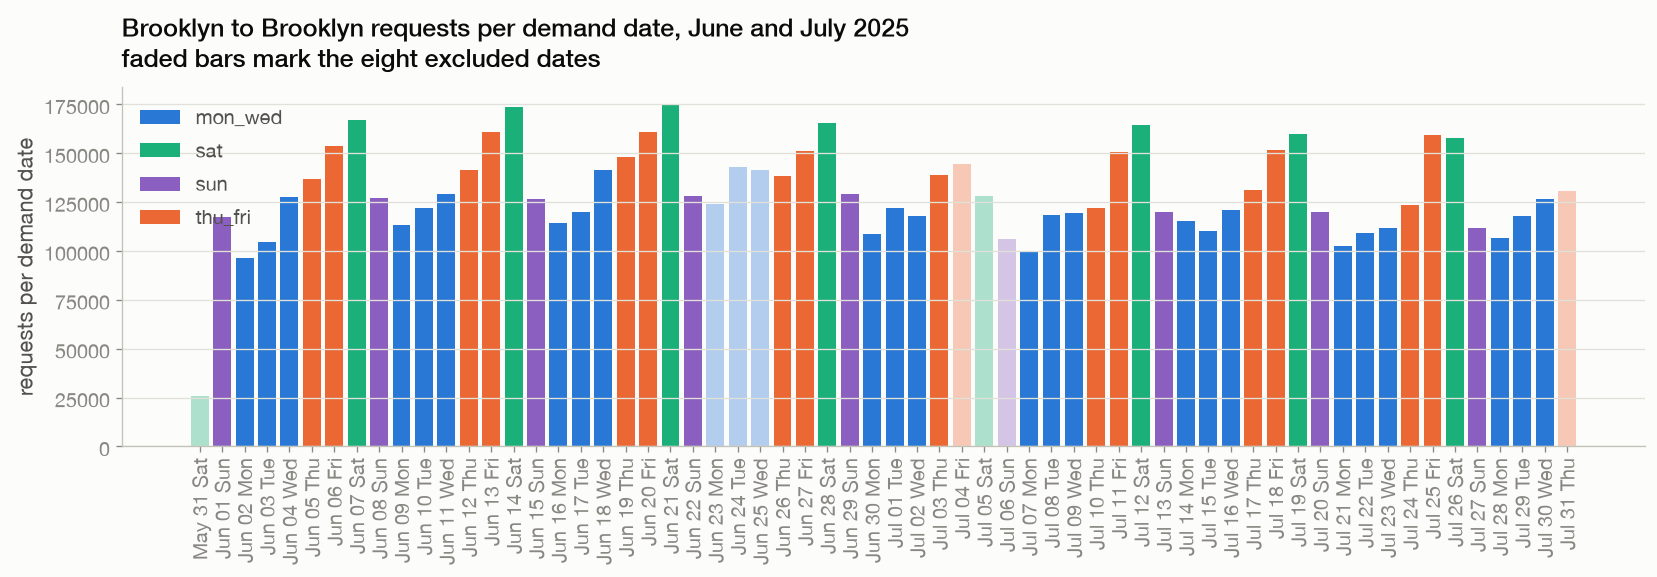

In [5]:
def daily_stats(by):
    g = FIT_DAYS.groupby(by).requests
    out = pd.DataFrame({"days": g.size(), "mean": g.mean().round(0), "sd": g.std().round(0),
                        "cv": (g.std() / g.mean()).round(3), "min": g.min(), "max": g.max()})
    return out

by_type = daily_stats("day_type")
by_dow = daily_stats("sim_dow")
by_dow.index = by_dow.index.map(DOW)
by_dow = by_dow.loc[["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]]

fig, ax = plt.subplots(figsize=(14, 5))
colors = {"mon_wed": "C0", "thu_fri": "C1", "sat": "C2", "sun": "C3"}
x = {d: i for i, d in enumerate(days.sim_day)}
for dt, g in days.groupby("day_type"):
    for in_fit, gg in g.groupby("in_fit"):
        ax.bar([x[d] for d in gg.sim_day], gg.requests, color=colors[dt],
               alpha=1.0 if in_fit else 0.35, label=dt if in_fit else None)
ax.set_xticks(range(len(days)))
ax.set_xticklabels([f"{d:%b %d} {w}" for d, w in zip(days.sim_day, days.weekday)], rotation=90)
ax.set_ylabel("requests per demand date")
ax.set_title("Brooklyn to Brooklyn requests per demand date, June and July 2025\n"
             "faded bars mark the eight excluded dates")
ax.legend()
fig.tight_layout()
display(by_type)
by_dow

---

### Summary

Mean demand increases from Monday through Saturday and declines on Sunday. Saturday has the highest
mean at approximately 166,000 requests, while Monday has the lowest weekday mean at approximately
107,000.

Across the four day types, the coefficient of variation ranges from 3.9 percent for Saturday to
8.8 percent for both weekday groups. Adding July does not uniformly reduce this measure. Relative to
June alone, the combined coefficient falls for `mon_wed` and rises for `thu_fri`, `sat`, and `sun`
because July has a lower mean on most weekdays. The larger sample improves coverage of rare demand
cells, while the difference between months adds temporal variation. Section 2.2 measures the monthly
difference directly.

## 2.1 Demand during the excluded event periods

The heat period was identified from the weather record in Notebook 02, and the Independence Day
period was identified from the calendar. The dates were specified before the comparisons below. The
analysis therefore measures the demand associated with each event; it does not select exclusions from
the largest observed deviations.

Each complete date is compared with the fitted dates of the same weekday and month, excluding the
target date. The percentage difference reports the change from that reference mean. The standardized
difference, `z`, divides the same change by the standard deviation among the reference dates. Each
reference contains only three or four dates, so `z` is sensitive to small reference variances and is
reported as a descriptive measure.

The first table reports the six excluded event dates. The second reports the ten largest absolute
standardized differences among all complete dates.

| Column | Meaning |
|---|---|
| `sim_day` | Demand date assigned using the 04:00 boundary |
| `weekday` | Weekday of the demand date |
| `requests` | Brooklyn to Brooklyn requests on the date |
| `baseline` | Mean for the fitted reference dates with the same weekday and month |
| `pct_vs_baseline` | Percentage difference from the reference mean |
| `z` | Difference measured in standard deviations of the reference dates |
| `in_fit` | Whether the date contributes to the fitted demand model |

Excluded event dates


,sim_day,weekday,requests,baseline,pct_vs_baseline,z,in_fit
8,2025-06-23,Mon,124163,108219,14.7,1.96,False
10,2025-06-24,Tue,143085,115575,23.8,2.88,False
11,2025-06-25,Wed,141564,132552,6.8,1.18,False
43,2025-07-04,Fri,144645,153950,-6.0,-1.91,False
44,2025-07-05,Sat,128336,160833,-20.2,-9.54,False
24,2025-07-06,Sun,106378,117153,-9.2,-2.27,False


Largest absolute standardized differences


,sim_day,weekday,requests,baseline,pct_vs_baseline,z,in_fit
0,2025-06-01,Sun,117281,127753,-8.2,-10.45,True
44,2025-07-05,Sat,128336,160833,-20.2,-9.54,False
5,2025-06-02,Mon,96523,112117,-13.9,-5.35,True
14,2025-06-19,Thu,147971,138900,6.5,4.08,True
26,2025-07-14,Mon,115446,103061,12.0,3.85,True
10,2025-06-24,Tue,143085,115575,23.8,2.88,False
39,2025-07-03,Thu,138811,125507,10.6,2.63,True
37,2025-07-23,Wed,111579,121294,-8.0,-2.55,True
24,2025-07-06,Sun,106378,117153,-9.2,-2.27,False
38,2025-07-30,Wed,126711,117511,7.8,2.23,True


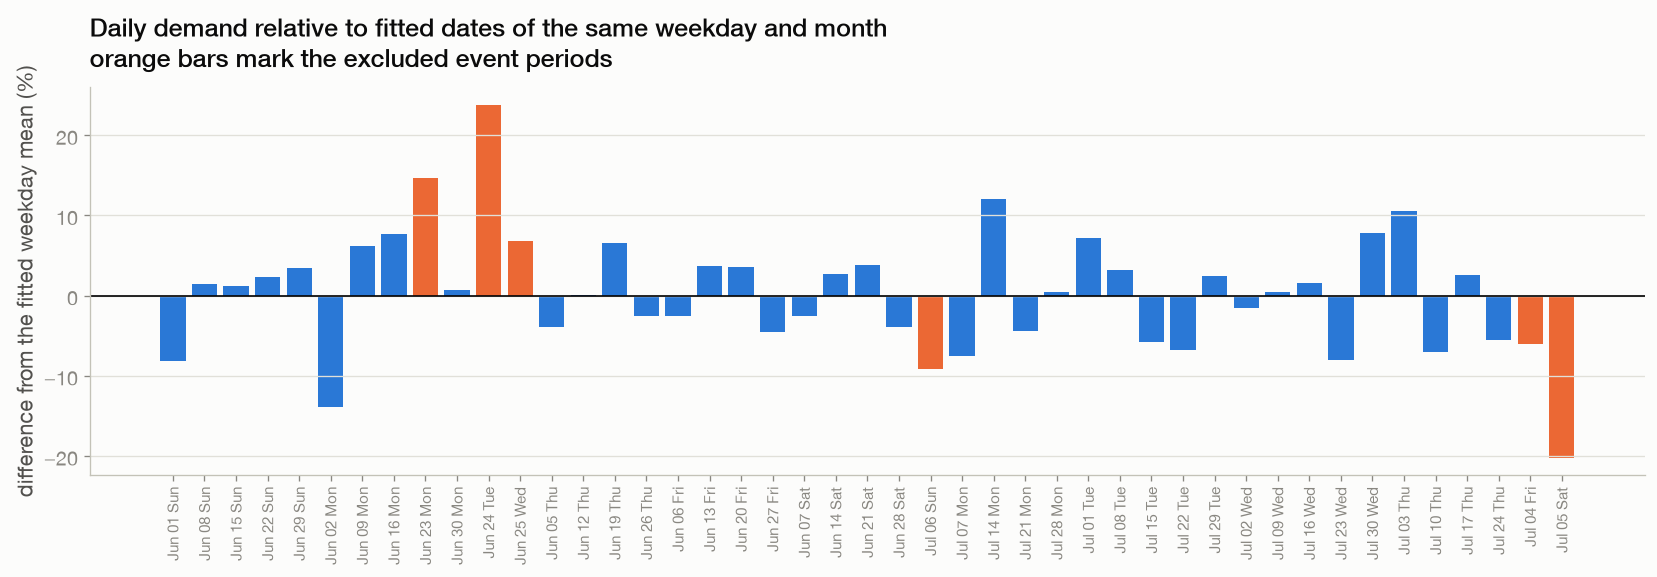

In [6]:
complete_days = days[
    (days.sim_day >= pd.Timestamp(FIRST_DAY)) &
    (days.sim_day <= pd.Timestamp(LAST_DAY))
]
loo = []
for (mon, dow), g in complete_days.groupby(
        [complete_days.sim_day.dt.to_period("M"), "sim_dow"]):
    for _, r in g.iterrows():
        reference = g[(g.sim_day != r.sim_day) & g.in_fit].requests
        if len(reference) < 3:
            continue
        loo.append({"sim_day": r.sim_day, "weekday": r.weekday, "requests": r.requests,
                    "baseline": round(reference.mean()),
                    "pct_vs_baseline": round(100 * (r.requests / reference.mean() - 1), 1),
                    "z": round((r.requests - reference.mean()) / reference.std(ddof=1), 2),
                    "in_fit": r.in_fit})
LOO = pd.DataFrame(loo)

fig, ax = plt.subplots(figsize=(14, 5))
col = np.where(LOO.in_fit, "#2a78d6", "#eb6834")
ax.bar(range(len(LOO)), LOO.pct_vs_baseline, color=col)
ax.axhline(0, color="k", lw=1)
ax.set_xticks(range(len(LOO)))
ax.set_xticklabels([f"{d:%b %d} {w}" for d, w in zip(LOO.sim_day, LOO.weekday)],
                   rotation=90, fontsize=9)
ax.set_ylabel("difference from the fitted weekday mean (%)")
ax.set_title("Daily demand relative to fitted dates of the same weekday and month\n"
             "orange bars mark the excluded event periods")
fig.tight_layout()

EVENT_COMPARISON = LOO[~LOO.in_fit].sort_values("sim_day")
TOP_DIFFERENCES = LOO.reindex(LOO.z.abs().sort_values(ascending=False).index).head(10)
print("Excluded event dates")
display(EVENT_COMPARISON)
print("Largest absolute standardized differences")
TOP_DIFFERENCES

---

### Summary

Demand is higher during each date of the June heat period: **14.7 percent** on 23 June,
**23.8 percent** on 24 June, and **6.8 percent** on 25 June relative to the corresponding weekday
means. Demand is lower throughout the Independence Day period: **6.0 percent** on 4 July,
**20.2 percent** on 5 July, and **9.2 percent** on 6 July.

The changes are consistent in direction within each three day event, but only 24 June and 5 July
exceed 15 percent. The comparison does not support a general 15 percent exclusion threshold. The
exclusions are based on externally identified events and the pattern across their adjacent dates.

The standardized differences illustrate the limits of the small reference samples. Demand on 1 June
is 8.2 percent below its comparison mean but has `z = -10.45`; demand on Juneteenth is 6.5 percent
above its comparison mean but has `z = 4.08`. Both remain in the fit. Their large standardized values
result from limited variation among the three or four comparison dates.

The fitted model therefore represents demand outside the two identified event periods. It does not
represent an unconditional summer date that may include holidays or severe weather. A disruption
analysis would specify those effects separately.

## 2.2 Comparison of June and July demand

Pooling June and July increases the number of observations available for each demand cell. It also
assumes that the level and distribution of demand are sufficiently similar across the two months.
This section compares three components:

* mean daily request volume for each weekday;
* the distribution of requests across hours;
* the distribution of request origins across the 20 decision zones.

Capture share scales the fitted request rates, but it does not remove uncertainty in the fitted demand
level. At a fixed capture share, a lower estimated market rate produces fewer offered requests.
Policies are evaluated against the same demand within each comparison, but a change in demand level
can still alter service and policy differences when the system approaches a capacity limit.
Demand level therefore remains a sensitivity parameter in the policy comparison.

Differences in hourly and spatial distributions are measured as half the sum of the absolute
differences between two profiles. A value of 3 percent means that 3 percent of requests would need to
be reassigned across hours or origin zones to make the profiles equal. For context, the June hourly
profiles differ by 2.1 percent between Monday and Tuesday and by 7.3 percent between Thursday and
Friday.

**Columns of the table below.** One row per weekday.

| Column | Meaning |
|---|---|
| `weekday` | Weekday |
| `june`, `july` | Mean Brooklyn to Brooklyn requests per fitted date in each month |
| `jul_vs_jun_pct` | Percentage difference between the July and June means |
| `hours_pct` | Difference between the monthly hourly distributions |
| `places_pct` | Difference between the monthly origin zone distributions |

,june,july,jul_vs_jun_pct,hours_pct,places_pct
weekday,,,,,
Mon,108219.0,106157.0,-1.9,2.39,1.21
Tue,115575.0,115606.0,0.0,3.89,1.27
Wed,132552.0,119351.0,-10.0,2.08,1.93
Thu,141168.0,128833.0,-8.7,2.16,2.66
Fri,156762.0,153950.0,-1.8,1.42,1.58
Sat,170342.0,160833.0,-5.6,1.66,1.97
Sun,125659.0,117153.0,-6.8,1.27,2.68


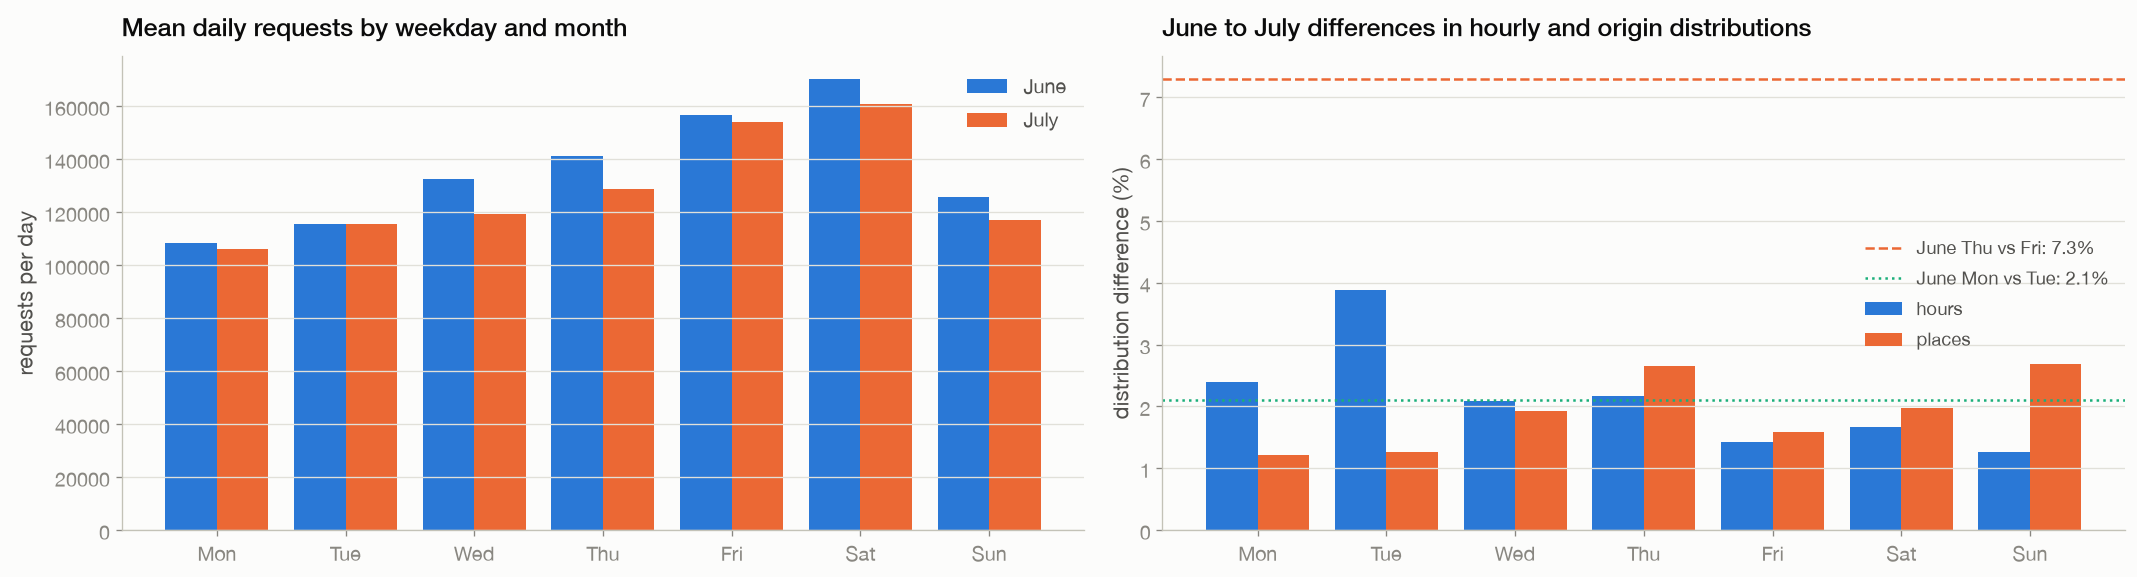

In [7]:
mon_col = days.sim_day.dt.to_period("M").astype(str)
fitdays = days[days.in_fit].assign(mon=mon_col[days.in_fit])
lvl = fitdays.groupby(["weekday", "mon"]).requests.mean().unstack()
lvl.columns = ["june", "july"]

hp2 = con.sql('''
SELECT strftime(sim_dt, '%Y-%m') AS mon, sim_dow, h, sim_dt, count(*) AS n
FROM q GROUP BY 1, 2, 3, 4''').df()
pr = hp2.groupby(["mon", "sim_dow", "h"]).n.mean().unstack("h")
sh2 = pr.div(pr.sum(axis=1), axis=0)

rows = []
for dow in range(7):
    a, b = sh2.loc[("2025-06", dow)], sh2.loc[("2025-07", dow)]
    rows.append({"weekday": DOW[dow],
                 "hours_pct": round(50 * (a - b).abs().sum(), 2)})
SHAPE = pd.DataFrame(rows).set_index("weekday")

# Apply the 20-zone map used in Section 4 to the monthly origin profiles.
_shp = zoning.shapes()
_lab20 = zoning.contiguous_labels(20, _shp, zoning.adjacency(_shp))

pp = con.sql('''
SELECT strftime(sim_dt, '%Y-%m') AS mon, sim_dow, o, count(*) AS n
FROM q GROUP BY 1, 2, 3''').df()
pp["place"] = pp.o.map(_lab20)
prp = pp.groupby(["mon", "sim_dow", "place"]).n.sum().unstack("place").fillna(0)
shp2 = prp.div(prp.sum(axis=1), axis=0)
SHAPE["places_pct"] = [round(50 * (shp2.loc[("2025-06", d)] - shp2.loc[("2025-07", d)]).abs().sum(), 2)
                       for d in range(7)]

OUT = lvl.round(0).join(SHAPE)
OUT["jul_vs_jun_pct"] = (100 * (OUT.july / OUT.june - 1)).round(1)
OUT = OUT.reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])[
    ["june", "july", "jul_vs_jun_pct", "hours_pct", "places_pct"]]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
x = np.arange(7)
axes[0].bar(x - 0.2, OUT.june, 0.4, label="June")
axes[0].bar(x + 0.2, OUT.july, 0.4, label="July")
axes[0].set_xticks(x); axes[0].set_xticklabels(OUT.index)
axes[0].set_ylabel("requests per day"); axes[0].legend()
axes[0].set_title("Mean daily requests by weekday and month")
axes[1].bar(x - 0.2, OUT.hours_pct, 0.4, label="hours")
axes[1].bar(x + 0.2, OUT.places_pct, 0.4, label="places")
axes[1].axhline(7.3, color="#eb6834", ls="--", lw=1.5,
                label="June Thu vs Fri: 7.3%")
axes[1].axhline(2.1, color="#1baf7a", ls=":", lw=1.5, label="June Mon vs Tue: 2.1%")
axes[1].set_xticks(x); axes[1].set_xticklabels(OUT.index)
axes[1].set_ylabel("distribution difference (%)")
axes[1].legend(fontsize=11)
axes[1].set_title("June to July differences in hourly and origin distributions")
fig.tight_layout()
OUT

---

### Summary

Mean July demand ranges from unchanged on Tuesday to 10.0 percent below June on Wednesday. At an
unchanged capture share, pooling the months therefore lowers offered demand relative to a June only
fit for most weekdays. This affects the operating load and may affect policy comparisons near capacity
limits.

The June to July difference in the hourly distribution ranges from **1.3 to 3.9 percent** across
weekdays. The difference in the origin zone distribution ranges from **1.2 to 2.7 percent**. These
values are comparable to or smaller than the within month differences between weekdays already
combined in the same demand type.

The results support pooling June and July for the spatial and hourly distribution of summer demand.
They do not show that monthly demand levels are interchangeable. The comparison also uses only three
to five observations per weekday and month, so it cannot separate seasonal change from sampling
variation with precision. Interpretation of capacity constrained results depends on sensitivity to
demand level. The fitted model does not represent other seasons.

## 3. Hourly demand profiles

The arrival sampler uses a separate request rate for each clock hour and holds that rate constant
within the hour. This section estimates the mean hourly profile for each day type and compares the
weekday profiles combined within those types.

Weekday labels refer to the demand date defined in Section 2. Requests from midnight through 03:59
therefore contribute to the preceding weekday profile.

Two measures compare normalized hourly profiles. Correlation measures whether two profiles rise and
fall together. Profile difference is half the sum of the absolute differences between their hourly
shares. A difference of 5 percent means that 5 percent of daily requests would need to move to another
hour for the profiles to match.

### Profiles for the four fitted day types

The solid line reports the mean requests per hour across fitted dates. The shaded interval extends
from the minimum to the maximum observed count for that hour. The vertical reference line marks the
04:00 boundary used to assign demand dates.

**Columns of the table below.** One row per fitted day type.

| Column | Meaning |
|---|---|
| `day_type` | Demand type |
| `peak_hour` | Clock hour with the highest mean request rate |
| `peak_per_h` | Mean requests during the peak hour |
| `trough_hour` | Clock hour with the lowest mean request rate |
| `trough_per_h` | Mean requests during the lowest hour |
| `peak_to_trough` | Peak rate divided by the lowest rate |

,day_type,peak_hour,peak_per_h,trough_hour,trough_per_h,peak_to_trough
0,mon_wed,18,7432,3,976,7.61
1,sat,23,10031,5,1949,5.15
2,sun,18,7508,3,1136,6.61
3,thu_fri,18,8991,4,1250,7.19


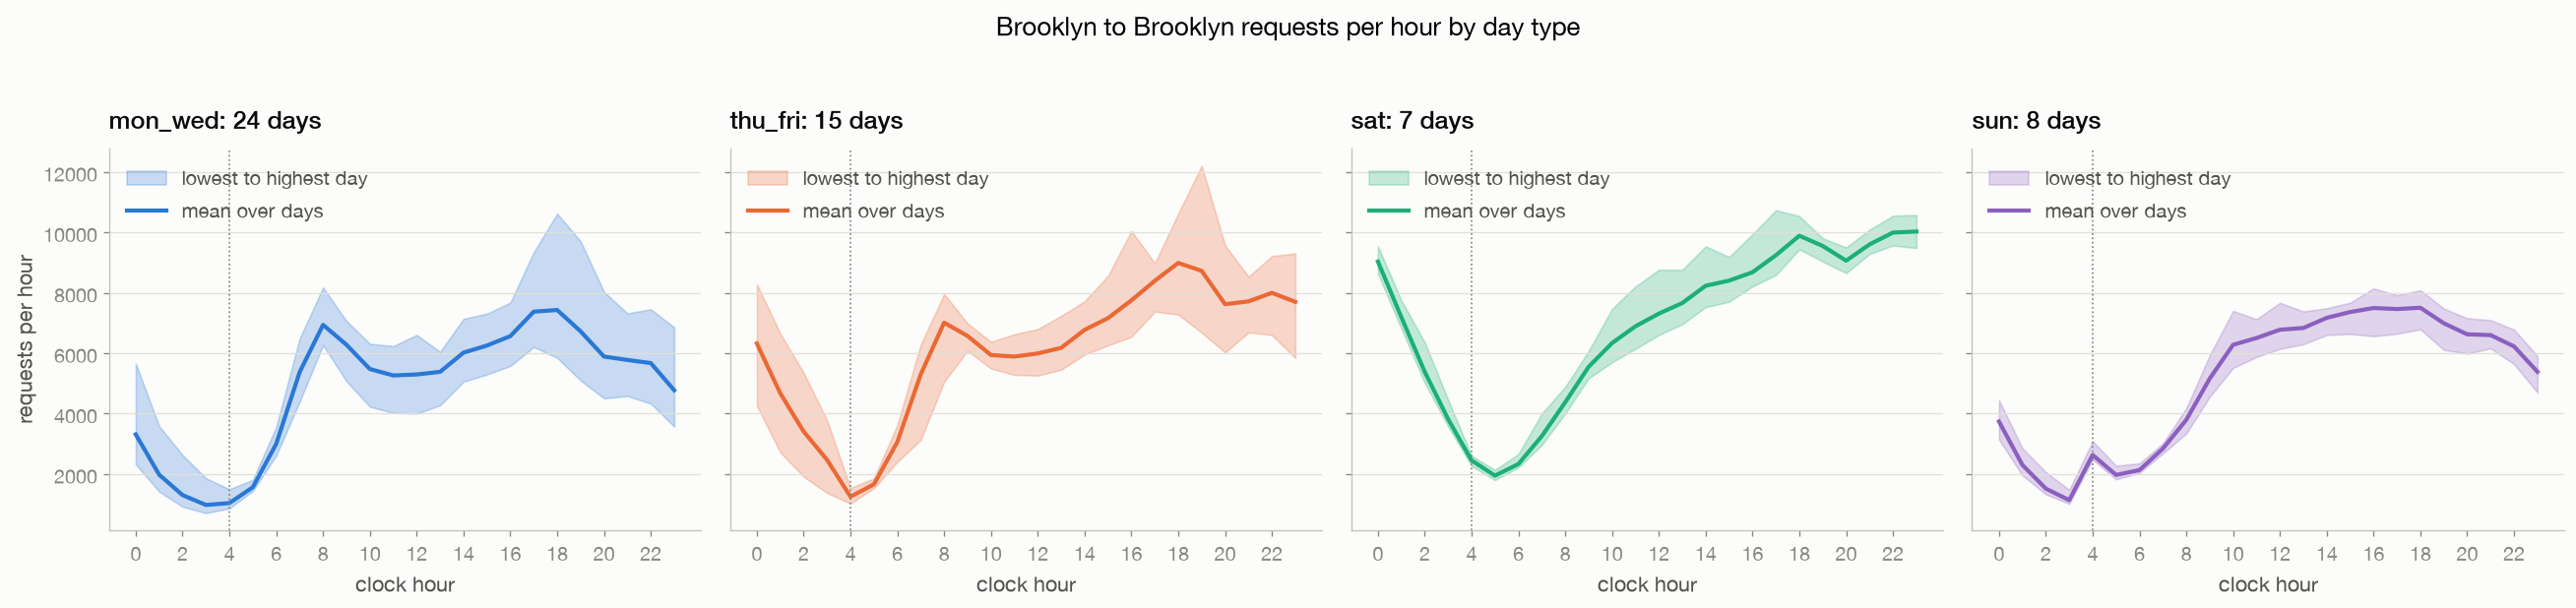

In [8]:
hourly = con.sql("SELECT day_type, h, sim_dt, count(*) AS n FROM q GROUP BY 1, 2, 3").df()
prof = hourly.groupby(["day_type", "h"]).n.agg(["mean", "min", "max"]).reset_index()

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
for ax, dt in zip(axes, DAY_TYPES):
    g = prof[prof.day_type == dt].sort_values("h")
    ax.fill_between(g.h, g["min"], g["max"], color=colors[dt], alpha=0.25, label="lowest to highest day")
    ax.plot(g.h, g["mean"], color=colors[dt], lw=2.5, label="mean over days")
    ax.axvline(4, color="grey", ls=":", lw=1)
    ax.set_title(f"{dt}: {N_DAYS[dt]} days")
    ax.set_xlabel("clock hour")
    ax.set_xticks(range(0, 24, 2))
    ax.legend(loc="upper left")
axes[0].set_ylabel("requests per hour")
fig.suptitle("Brooklyn to Brooklyn requests per hour by day type", y=1.03)
fig.tight_layout()

rows = []
for dt, g in prof.groupby("day_type"):
    pk, tr = g.loc[g["mean"].idxmax()], g.loc[g["mean"].idxmin()]
    rows.append({"day_type": dt, "peak_hour": int(pk.h), "peak_per_h": round(pk["mean"]),
                 "trough_hour": int(tr.h), "trough_per_h": round(tr["mean"]),
                 "peak_to_trough": round(pk["mean"] / tr["mean"], 2)})
pd.DataFrame(rows)

---

### Summary

The mean profiles for `mon_wed`, `thu_fri`, and `sun` reach their maximum at 18:00. Saturday reaches
its maximum at 23:00 and has the highest peak rate, approximately 10,000 requests per hour. Peak rates
for the other types range from approximately 7,400 to 9,000 requests per hour.

The minimum occurs between 03:00 and 05:00, depending on the day type. Peak to trough ratios range
from 5.15 on Saturday to 7.61 for Monday through Wednesday. Saturday's lower ratio reflects relatively
high late night demand rather than a lower peak.

These profiles define the hourly demand rates. They do not prescribe when an evaluation period begins.

### 3.1 Evaluation of the weekday groupings

The first table reports correlations between normalized hourly profiles. The second reports profile
differences in percentage points of daily demand. Both matrices are symmetric and use demand weekdays
from Monday through Sunday.

Peak hour by demand weekday: {'Mon': 17, 'Tue': 18, 'Wed': 18, 'Thu': 18, 'Fri': 18, 'Sat': 23, 'Sun': 18}
Hourly profile correlations


,Mon,Tue,Wed,Thu,Fri,Sat,Sun
Mon,1.000,0.993,0.975,0.938,0.696,0.526,0.833
Tue,0.993,1.000,0.991,0.970,0.767,0.610,0.858
Wed,0.975,0.991,1.000,0.987,0.830,0.682,0.865
Thu,0.938,0.970,0.987,1.000,0.889,0.778,0.893
Fri,0.696,0.767,0.830,0.889,1.000,0.917,0.721
Sat,0.526,0.610,0.682,0.778,0.917,1.000,0.776
Sun,0.833,0.858,0.865,0.893,0.721,0.776,1.000


Hourly profile differences (%)


,Mon,Tue,Wed,Thu,Fri,Sat,Sun
Mon,0.0,2.3,4.1,6.5,13.2,15.4,8.8
Tue,2.3,0.0,2.7,4.4,11.5,14.0,8.3
Wed,4.1,2.7,0.0,2.5,9.2,11.6,7.7
Thu,6.5,4.4,2.5,0.0,7.3,9.7,7.9
Fri,13.2,11.5,9.2,7.3,0.0,5.1,12.6
Sat,15.4,14.0,11.6,9.7,5.1,0.0,11.2
Sun,8.8,8.3,7.7,7.9,12.6,11.2,0.0


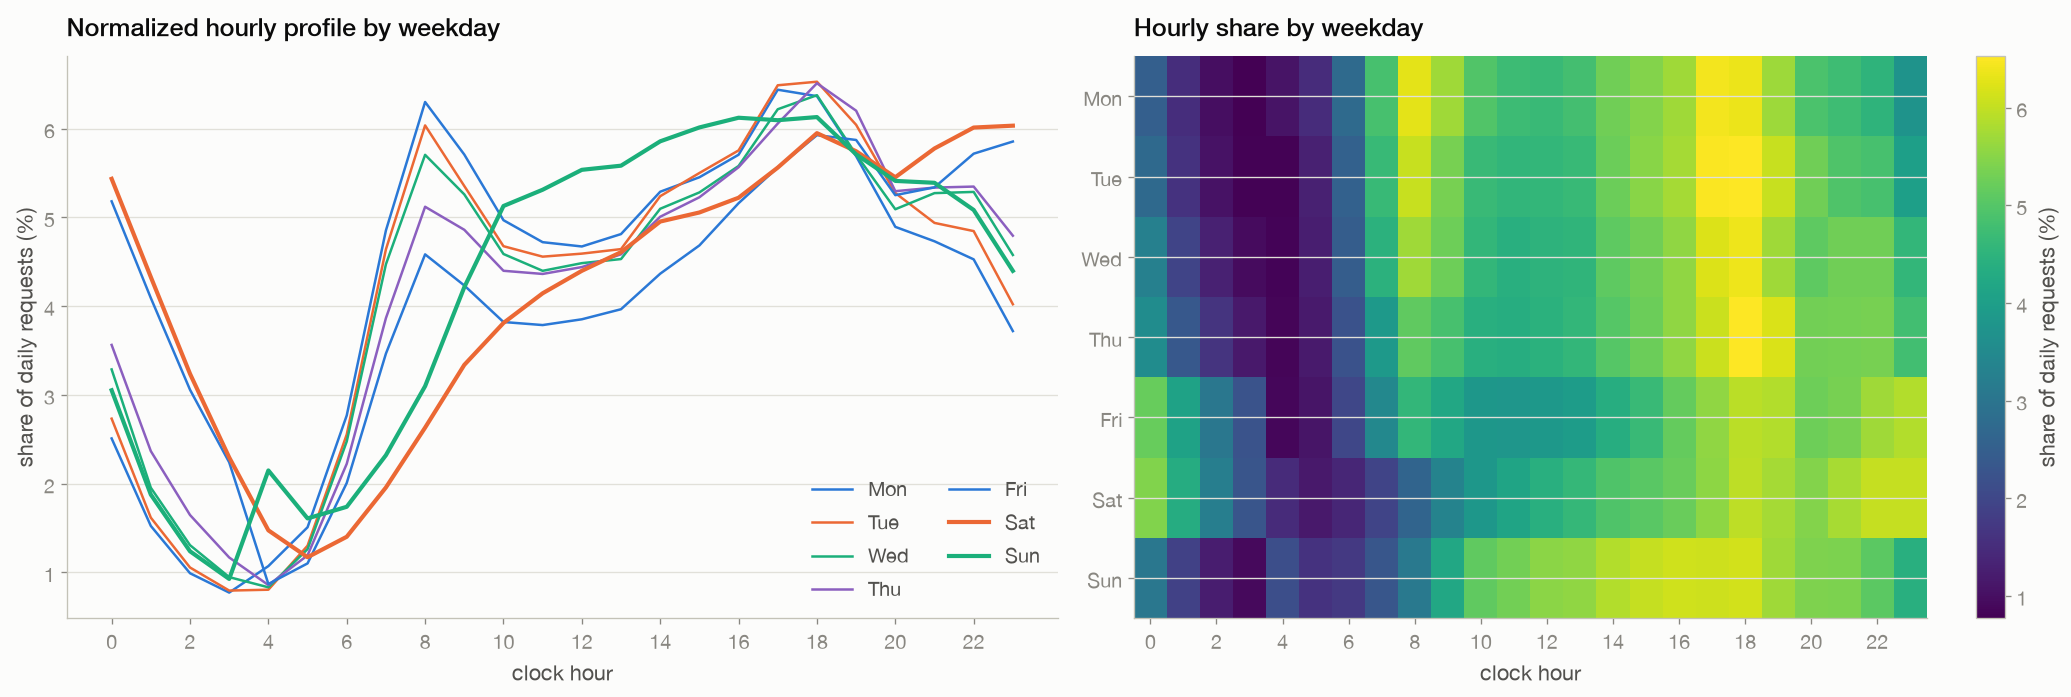

In [9]:
dow_hourly = con.sql("SELECT sim_dow, h, sim_dt, count(*) AS n FROM q GROUP BY 1, 2, 3").df()
dow_prof = dow_hourly.groupby(["sim_dow", "h"]).n.mean().unstack("h")
dow_share = dow_prof.div(dow_prof.sum(axis=1), axis=0)
order = [1, 2, 3, 4, 5, 6, 0]
dow_share = dow_share.loc[order]
dow_share.index = [DOW[i] for i in order]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for name, row in dow_share.iterrows():
    axes[0].plot(row.index, 100 * row.values,
                 lw=2.5 if name in ("Sat", "Sun") else 1.5, label=name)
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_xlabel("clock hour")
axes[0].set_ylabel("share of daily requests (%)")
axes[0].set_title("Normalized hourly profile by weekday")
axes[0].legend(ncol=2)

im = axes[1].imshow(100 * dow_share.values, aspect="auto", cmap="viridis")
axes[1].set_yticks(range(7))
axes[1].set_yticklabels(dow_share.index)
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_xlabel("clock hour")
axes[1].set_title("Hourly share by weekday")
fig.colorbar(im, ax=axes[1], label="share of daily requests (%)")
fig.tight_layout()

corr = dow_share.T.corr().round(3)
profile_diff = pd.DataFrame({
    a: {b: round(50 * (dow_share.loc[a] - dow_share.loc[b]).abs().sum(), 1)
        for b in dow_share.index}
    for a in dow_share.index
}).T
peaks = pd.Series({d: int(dow_share.loc[d].idxmax()) for d in dow_share.index},
                  name="peak_hour")
print("Peak hour by demand weekday:", peaks.to_dict())
print("Hourly profile correlations")
display(corr)
print("Hourly profile differences (%)")
profile_diff

---

### Summary

The Monday, Tuesday, and Wednesday profiles are similar. Their pairwise correlations range from
0.975 to 0.993, and their profile differences range from 2.3 to 4.1 percent. Combining these weekdays
is reasonable for hourly shape, although their mean daily volumes increase from approximately 107,000
on Monday to 124,000 on Wednesday.

The evidence for combining Thursday and Friday is weaker. Their correlation is 0.889, their profile
difference is 7.3 percent, and mean daily demand rises from approximately 135,000 to 156,000. Friday
is closer to Saturday in hourly shape, with a correlation of 0.917 and a profile difference of
5.1 percent. The current `thu_fri` type therefore smooths a material difference.

Separating Saturday and Sunday is supported by both shape and level. Their profile difference is
11.2 percent, their correlation is 0.776, and Saturday demand is approximately 36 percent higher.
Saturday peaks at 23:00, while Sunday peaks at 18:00.

The fitted artifact retains the current four day types for consistency with the completed experimental
results. An alternative contiguous partition of Monday and Tuesday, Wednesday and Thursday, Friday
and Saturday, and Sunday has within group profile differences of 2.3, 2.5, and 5.1 percent for its
three nonsingleton groups. The notebook does not compare these alternatives on out of sample demand or
policy outcomes, so the artifact is unchanged. The heterogeneity within `thu_fri` remains a model
limitation.

## 4. Construction of the 20 zone demand model

A demand cell is defined by day type, origin decision zone, destination decision zone, and clock hour.
Its fitted rate is the observed request count divided by the number of calibration dates for that day
type. Four day types, 20 origins, 20 destinations, and 24 hours produce **38,400 cells**, including
cells with no observed requests.

The demand and travel models use the same decision zone map so that every origin and destination in
the demand model has a corresponding travel distribution. Notebook 04 constructs this map by merging
the 61 Brooklyn taxi zones into 20 contiguous decision zones. Section 7 examines the sensitivity of
demand coverage to alternative zone counts.

### Decision zone mapping

The following listing reports the taxi zones assigned to each decision zone. The map is reconstructed
with the same `contiguous_labels` function and zone count used in Notebook 04.

In [10]:
N_PLACES = 20
shp = zoning.shapes()                     # Brooklyn's 61 taxi-zone polygons, feet
adj = zoning.adjacency(shp)               # which zones touch, at a 50 ft tolerance
ZONING = zoning.contiguous_labels(N_PLACES, shp, adj)


def publish(lab, view="mp"):
    # Make a label map visible to SQL as a two-column view.
    vals = ",".join(f"({a},{b})" for a, b in lab.items())
    con.execute(f"CREATE OR REPLACE TEMP VIEW {view} AS SELECT * FROM (VALUES {vals}) AS m(lid, z)")

publish(ZONING)
shp["place"] = shp.LocationID.map(ZONING)
listing = shp.groupby("place").zone.apply(lambda s: ", ".join(sorted(s)))
print(f"{N_PLACES} decision zones\n")
for p, names in listing.items():
    print(f"  zone {p:>2}: {names}")

20 decision zones

  zone  0: Brownsville, Cypress Hills, East New York/Pennsylvania Avenue, Ocean Hill
  zone  1: Bedford, Bushwick North, Bushwick South, Stuyvesant Heights
  zone  2: Canarsie, East New York, Starrett City
  zone  3: East Flatbush/Farragut, East Flatbush/Remsen Village, Erasmus
  zone  4: Homecrest, Madison, Midwood, Ocean Parkway South
  zone  5: Boerum Hill, Brooklyn Heights, Cobble Hill, Columbia Street, DUMBO/Vinegar Hill, Downtown Brooklyn/MetroTech
  zone  6: Carroll Gardens, Gowanus, Park Slope, Red Hook
  zone  7: Bath Beach, Bensonhurst East, Bensonhurst West
  zone  8: East Williamsburg, Greenpoint, Williamsburg (North Side)
  zone  9: Borough Park, Flatbush/Ditmas Park, Kensington
  zone 10: Brighton Beach, Manhattan Beach, Sheepshead Bay
  zone 11: Flatlands, Marine Park/Mill Basin
  zone 12: Clinton Hill, Fort Greene, Prospect Heights
  zone 13: Bay Ridge, Dyker Heights
  zone 14: Sunset Park East, Sunset Park West
  zone 15: Coney Island, Gravesend
  zo

---

### Summary

The 20 decision zones form the common spatial index for the demand and travel models. Each zone
contains between one and six TLC taxi zones. Using a common index ensures that every demand cell can
be evaluated with the corresponding travel time and distance distributions. The choice of 20 zones
remains a modeling decision rather than an estimate from demand data.

**Columns of the table below.** One row per day type. Each day type contains 9,600 cells.

| Column | Meaning |
|---|---|
| `day_type` | Demand type |
| `days` | Number of fitted demand dates |
| `cells` | Number of origin, destination, and hour combinations |
| `empty` | Cells with no observed requests |
| `pct_empty` | Empty cells as a percentage of all cells |
| `under_1_per_hour` | Cells with a fitted rate below one request per hour, including empty cells |
| `pct_under_1` | Percentage of cells with a rate below one request per hour |
| `median_rate_per_hour` | Median fitted rate across all cells |
| `top10pct_share` | Share of requests in the 10 percent of cells with the highest rates |
| `same_zone_share` | Share of requests whose endpoints are in the same decision zone |

,day_type,days,cells,empty,pct_empty,under_1_per_hour,pct_under_1,median_rate_per_hour,top10pct_share,same_zone_share
0,mon_wed,24,9600,404,4.2,2806,29.2,2.79,0.586,0.313
1,sat,7,9600,512,5.3,1901,19.8,4.29,0.582,0.267
2,sun,8,9600,602,6.3,2445,25.5,3.00,0.585,0.283
3,thu_fri,15,9600,409,4.3,2276,23.7,3.60,0.581,0.299


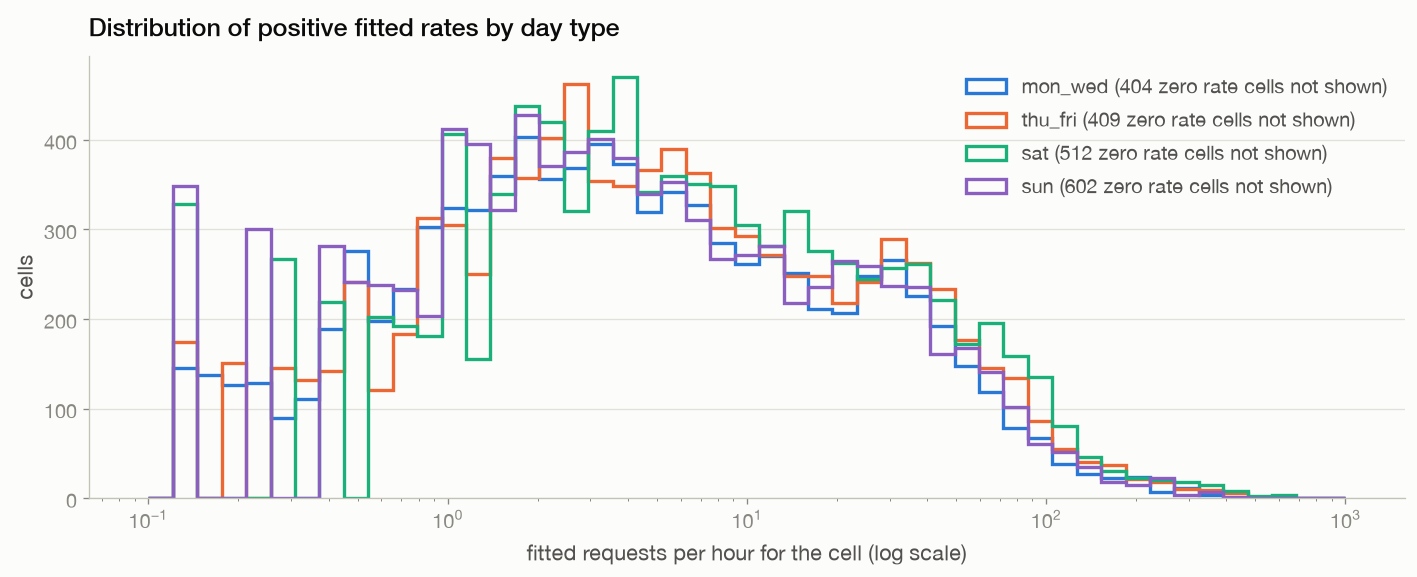

In [11]:
def rate_grid(k, lab):
    publish(lab)
    obs = con.sql("""
    SELECT day_type, mo.z AS zo, md.z AS zd, h, count(*) AS n
    FROM q JOIN mp mo ON q.o = mo.lid JOIN mp md ON q.d = md.lid
    GROUP BY 1, 2, 3, 4 ORDER BY 1, 2, 3, 4
    """).df()
    grid = pd.MultiIndex.from_product([DAY_TYPES, range(k), range(k), range(24)],
                                      names=["day_type", "zo", "zd", "h"]).to_frame(index=False)
    grid = grid.merge(obs, how="left").fillna({"n": 0})
    grid["n"] = grid.n.astype(int)
    grid["days"] = grid.day_type.map(N_DAYS)
    grid["rate"] = grid.n / grid.days
    return grid

GRID = rate_grid(N_PLACES, ZONING)

rows = []
for dt, g in GRID.groupby("day_type"):
    tot = g.n.sum()
    top = g.n.sort_values(ascending=False).head(len(g) // 10).sum()
    rows.append({"day_type": dt, "days": N_DAYS[dt], "cells": len(g),
                 "empty": int((g.n == 0).sum()), "pct_empty": round(100 * (g.n == 0).mean(), 1),
                 "under_1_per_hour": int((g.rate < 1).sum()), "pct_under_1": round(100 * (g.rate < 1).mean(), 1),
                 "median_rate_per_hour": round(g.rate.median(), 2),
                 "top10pct_share": round(top / tot, 3),
                 "same_zone_share": round(g[g.zo == g.zd].n.sum() / tot, 3)})
CELL_STATS = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 5))
bins = np.logspace(-1, 3, 50)
for dt in DAY_TYPES:
    r = GRID[(GRID.day_type == dt) & (GRID.n > 0)].rate
    ax.hist(r, bins=bins, histtype="step", lw=2, color=colors[dt], label=f"{dt} ({(GRID.day_type == dt).sum() - len(r)} zero rate cells not shown)")
ax.set_xscale("log")
ax.set_xlabel("fitted requests per hour for the cell (log scale)"); ax.set_ylabel("cells")
ax.set_title("Distribution of positive fitted rates by day type")
ax.legend()
fig.tight_layout()
CELL_STATS

---

### Summary

Empty cells account for **4.2 to 6.3 percent** of each day type. Between **19.8 and 29.2 percent** of
cells have fitted rates below one request per hour, and the median rate ranges from 2.79 to 4.29
requests per hour. Demand is concentrated: the 10 percent of cells with the highest rates account for
approximately 58 percent of requests in every day type.

Empty cell prevalence reflects both the number of calibration dates and the level of demand. Saturday
has only seven fitted dates but the lowest share of cells below one request per hour because it has the
highest daily volume. Sunday has eight dates and the highest empty cell share.

Adding July reduced the empty cell share from 7.2 to 4.2 percent for `mon_wed`, from 5.9 to 4.3
percent for `thu_fri`, from 8.1 to 5.3 percent for `sat`, and from 8.6 to 6.3 percent for `sun`.
These are reductions of 27 to 42 percent relative to the June only estimates.

Between 26.7 and 31.3 percent of requests begin and end in the same decision zone. These trips still
have positive travel time and distance; they use the diagonal cells of the travel model. Their share
also shows how the 20 zone aggregation conceals movement within each decision zone.

### 4.1 Treatment of unobserved cells

The fitted artifact assigns a rate of zero to a cell with no observed requests. Zero observations do
not establish that the underlying request rate is zero.

Under a stationary Poisson assumption, an empty cell observed over `n` demand dates has a one sided
95 percent upper rate limit of approximately `3 / n` requests per hour. The first table applies this
rule to every empty cell. `sum_of_cell_limits` adds the individual limits and expresses the result as
a share of mean daily demand.

This sum is a conservative sensitivity calculation, not a joint 95 percent confidence bound. The
individual limits are marginal, and applying all of them simultaneously does not preserve 95 percent
coverage for their sum. Section 10.1 provides a separate empirical assessment using August data.

**Columns of the first table.**

| Column | Meaning |
|---|---|
| `day_type` | Demand type |
| `empty_cells` | Cells with no observed requests |
| `per_cell_limit` | Approximate one sided 95 percent upper rate limit for one empty cell |
| `sum_of_cell_limits` | Sum of the individual limits, in expected requests per demand date |
| `share_of_daily_demand` | Sum of the limits as a percentage of mean daily demand |

**Columns of the second table.** One row per decision zone, ordered by origin request volume.

| Column | Meaning |
|---|---|
| `place` | Decision zone number |
| `requests_per_day` | Mean Monday through Wednesday requests originating in the zone |
| `share_of_empty_cells` | Share of empty Monday through Wednesday cells involving the zone as an origin or destination |

In [12]:
rows = []
for dt, g in GRID.groupby("day_type"):
    empty_count = int((g.n == 0).sum())
    per_cell_limit = 3 / N_DAYS[dt]
    summed_limits = empty_count * per_cell_limit
    mean_daily_demand = g.n.sum() / N_DAYS[dt]
    rows.append({"day_type": dt,
                 "empty_cells": empty_count,
                 "per_cell_limit": round(per_cell_limit, 3),
                 "sum_of_cell_limits": round(summed_limits, 1),
                 "share_of_daily_demand": round(100 * summed_limits / mean_daily_demand, 2)})
display(pd.DataFrame(rows))

mw = GRID[GRID.day_type == "mon_wed"]
per_place = mw.groupby("zo").n.sum() / N_DAYS["mon_wed"]
empty = mw[mw.n == 0]
touch = pd.Series({p: ((empty.zo == p) | (empty.zd == p)).sum()
                   for p in range(N_PLACES)})
PLACE_VOL = pd.DataFrame({
    "place": range(N_PLACES),
    "requests_per_day": per_place.round(0).values,
    "share_of_empty_cells": (touch / len(empty)).round(3).values,
}).sort_values("requests_per_day").reset_index(drop=True)
PLACE_VOL

,day_type,empty_cells,per_cell_limit,sum_of_cell_limits,share_of_daily_demand
0,mon_wed,404,0.125,50.5,0.04
1,sat,512,0.429,219.4,0.13
2,sun,602,0.375,225.8,0.18
3,thu_fri,409,0.200,81.8,0.06


,place,requests_per_day,share_of_empty_cells
0,16,48.0,0.938
1,19,927.0,0.131
2,15,2452.0,0.037
3,18,3595.0,0.124
4,10,3749.0,0.027
5,13,3846.0,0.059
6,14,3968.0,0.059
7,7,4119.0,0.037
8,11,4364.0,0.020
9,4,5473.0,0.010


---

### Summary

The sum of the individual cell limits ranges from **0.04 percent** of mean demand for `mon_wed` to
**0.18 percent** for `sun`. These percentages describe a deliberately conservative sensitivity total.
They are not simultaneous confidence bounds on omitted demand.

Decision zone 16, Marine Park and Floyd Bennett Field, has approximately **48 origin requests per
Monday through Wednesday date**. The next smallest zone has approximately 927, while the largest has
more than 12,000. Zone 16 appears as an origin or destination in **93.8 percent** of empty cells. The
zero rate assumption is therefore concentrated in one low volume geographic area.

The artifact retains zero rates for unobserved cells. This avoids adding spatial and temporal patterns
without observations, but it understates rare combinations that did not occur during calibration.
Section 10.1 measures those omissions against August. Smoothing across adjacent zones or hours would
require separate validation and would change the fitted artifact.

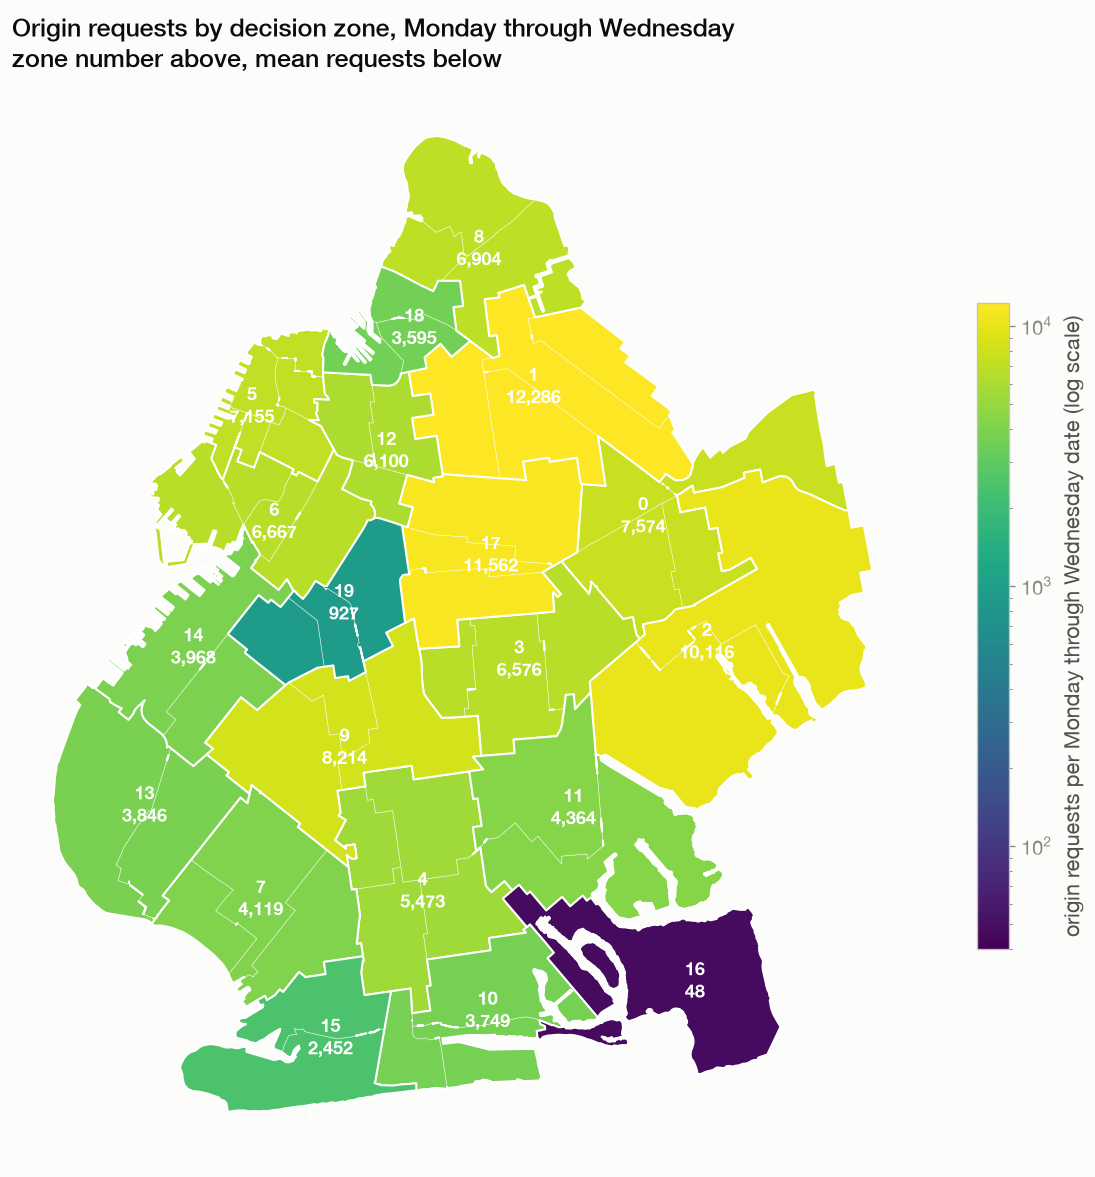

In [13]:
fig, ax = plt.subplots(figsize=(11, 10))
g = shp.dissolve(by="place")
g["requests_per_day"] = per_place
g.plot(column="requests_per_day", ax=ax, cmap="viridis", norm=LogNorm(vmin=40, vmax=per_place.max()),
       edgecolor="white", linewidth=1.2, legend=True,
       legend_kwds={"label": "origin requests per Monday through Wednesday date (log scale)", "shrink": 0.6})
shp.boundary.plot(ax=ax, color="white", linewidth=0.3, alpha=0.7)
for p, geom in zip(g.index, g.geometry):
    c = geom.representative_point()
    ax.annotate(f"{p}\n{per_place[p]:,.0f}", (c.x, c.y), ha="center", va="center", fontsize=11,
                color="white", weight="bold")
ax.set_axis_off()
ax.set_title("Origin requests by decision zone, Monday through Wednesday\nzone number above, mean requests below")
fig.tight_layout()

---

### Summary

Origin demand is concentrated in northern and central Brooklyn. Decision zones 1, 17, and 2 have the
highest mean origin volumes. Demand is lower along the southern edge of the borough, and zone 16 is a
large geographic area with very little observed demand.

Origin volume alone does not determine vehicle availability because destinations also affect the
spatial distribution of vehicles. Section 6 measures the net movement produced by the full origin and
destination demand model.

## 5. Assessment of the Poisson arrival model

Within each day type, origin zone, destination zone, and hour cell, the demand model generates requests
from a homogeneous Poisson process. The fitted rate is constant within the hour and across dates of
the same day type.

Two implications can be evaluated from the trip records:

* A fixed Poisson count has equal mean and variance. The index of dispersion, calculated as variance
  divided by mean across dates, should therefore be close to one.
* Conditional on an hourly count, request times are uniformly distributed within the hour. The four
  quarter hours should therefore contain approximately equal shares of requests.

The dispersion comparison uses an approximate chi squared interval. With 7 dates, the central
95 percent range is approximately 0.21 to 2.41; with 24 dates, it is approximately 0.51 to 1.67.
These intervals are wide for the weekend types and approximate for cells with small means.

### Scope of the assessment

The tests below examine fixed rates and within hour uniformity. They do not test independence between
demand cells or identify the source of excess variation. A result inside the Poisson range is also
not proof of a Poisson process, particularly for rare cells with few observations.

**Columns of the table below.** Cells with at least one calibration request, grouped by their mean
count per demand date.

| Column | Meaning |
|---|---|
| `band` | Mean requests per demand date for the origin, destination, and hour cell |
| `cells` | Number of cells in the band across all day types |
| `req_share` | Share of requests represented by the band |
| `p10`, `median`, `p90` | Percentiles of the index of dispersion |
| `pct_above_approx_range` | Percentage of cells above the approximate 95 percent Poisson range for their number of dates |

,cells,req_share,p10,median,p90,pct_above_approx_range
band,,,,,,
under 0.5,4640.0,0.002,0.71,1.00,1.44,2.2
0.5 to 2,8404.0,0.019,0.50,0.96,1.64,4.1
2 to 5,7386.0,0.044,0.50,0.99,1.83,7.5
5 to 20,8624.0,0.162,0.54,1.11,2.32,13.8
over 20,7419.0,0.773,0.70,1.64,5.20,38.5


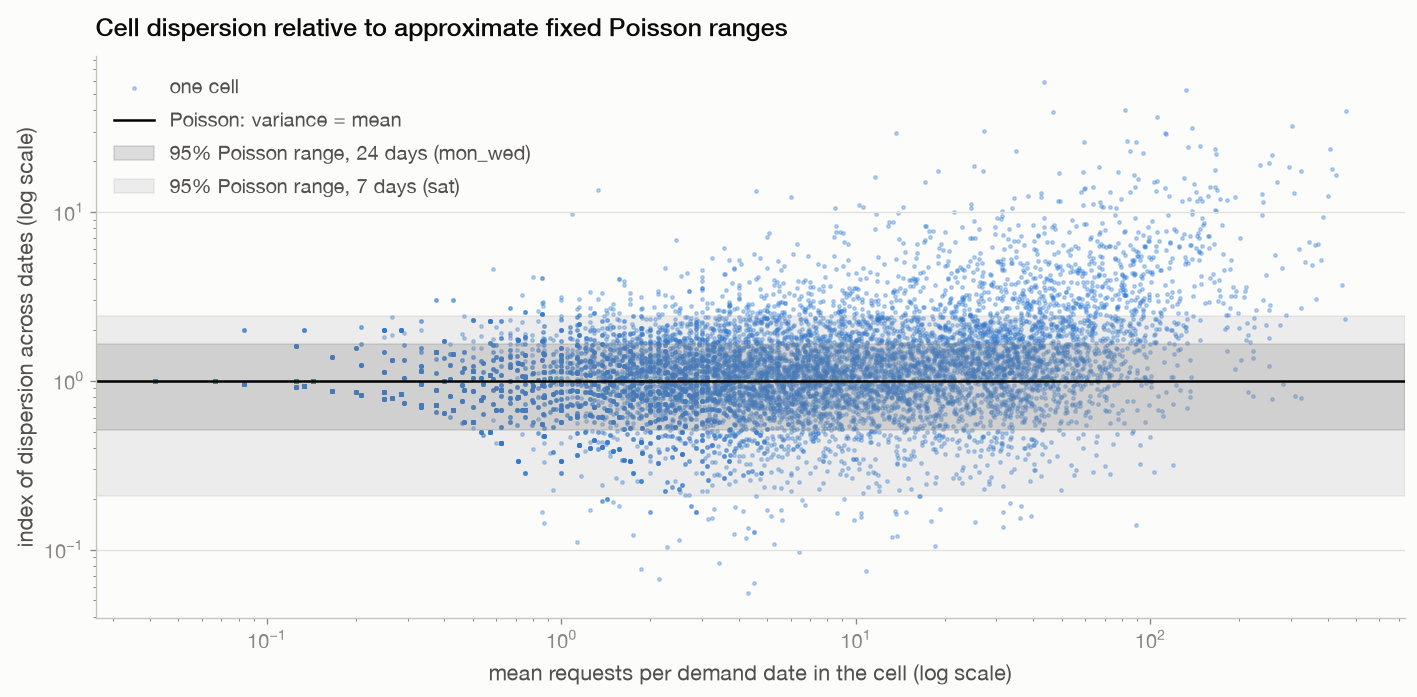

In [14]:
per_day = con.sql("""
SELECT day_type, mo.z AS zo, md.z AS zd, h, sim_dt, count(*) AS n
FROM q JOIN mp mo ON q.o = mo.lid JOIN mp md ON q.d = md.lid
GROUP BY 1, 2, 3, 4, 5 ORDER BY 1, 2, 3, 4, 5
""").df()
fit_days = FIT_DAYS.rename(columns={"sim_day": "sim_dt"})[["sim_dt", "day_type"]]
nonempty = GRID[GRID.n > 0][["day_type", "zo", "zd", "h"]]
expanded = (nonempty.merge(fit_days, on="day_type")          # every fit day, so zeros count
                    .merge(per_day, how="left").fillna({"n": 0}))
disp = expanded.groupby(["day_type", "zo", "zd", "h"]).n.agg(["mean", "var", "count"]).reset_index()
disp["ratio"] = disp["var"] / disp["mean"]
disp["upper_approx_95"] = disp["count"].map(lambda n: stats.chi2.ppf(0.975, n - 1) / (n - 1))
disp["band"] = pd.cut(disp["mean"], [0, 0.5, 2, 5, 20, 1e9],
                      labels=["under 0.5", "0.5 to 2", "2 to 5", "5 to 20", "over 20"])
DISP = disp

tab = disp.groupby("band", observed=True).apply(lambda g: pd.Series({
    "cells": len(g), "req_share": round(g["mean"].sum() / disp["mean"].sum(), 3),
    "p10": round(g.ratio.quantile(0.1), 2), "median": round(g.ratio.median(), 2),
    "p90": round(g.ratio.quantile(0.9), 2),
    "pct_above_approx_range": round(100 * (g.ratio > g.upper_approx_95).mean(), 1)}), include_groups=False)

fig, ax = plt.subplots(figsize=(12, 6))
s = disp.sample(min(len(disp), 12000), random_state=SEED)
ax.scatter(s["mean"], s.ratio, s=4, alpha=0.3, color="C0", label="one cell")
ax.axhline(1, color="k", lw=1.5, label="Poisson: variance = mean")
_nmw, _nsat = N_DAYS["mon_wed"], N_DAYS["sat"]
ax.axhspan(stats.chi2.ppf(0.025, _nmw - 1) / (_nmw - 1), stats.chi2.ppf(0.975, _nmw - 1) / (_nmw - 1),
           color="grey", alpha=0.25, label=f"95% Poisson range, {_nmw} days (mon_wed)")
ax.axhspan(stats.chi2.ppf(0.025, _nsat - 1) / (_nsat - 1), stats.chi2.ppf(0.975, _nsat - 1) / (_nsat - 1),
           color="grey", alpha=0.12, label=f"95% Poisson range, {_nsat} days (sat)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("mean requests per demand date in the cell (log scale)"); ax.set_ylabel("index of dispersion across dates (log scale)")
ax.set_title("Cell dispersion relative to approximate fixed Poisson ranges")
ax.legend(loc="upper left")
fig.tight_layout()
tab

---

### Summary

Cells with fewer than five requests per demand date have median dispersion ratios near one. These
cells carry only 6.5 percent of requests, and their short count series have limited power to distinguish
Poisson variation from date level changes.

Cells with more than 20 requests per demand date carry **77.3 percent of requests**. Their median
index of dispersion is **1.64**, and **38.5 percent** exceed the approximate upper Poisson limit for
their number of calibration dates. Under the reference model, approximately 2.5 percent would be
expected above this upper limit.

The increase in dispersion with cell volume is evidence against one fixed rate for every date of a
day type. It is consistent with common date level changes that affect many cells at once. The analysis
does not separate those changes from residual weekday differences within `mon_wed` and `thu_fri`, or
from the difference between June and July.

### 5.1 Variation in total and hourly demand across dates

If all demand cells had independent fixed Poisson rates, their sum would also be Poisson. Mean daily
demand ranges from approximately 116,000 to 166,000 requests across the four day types, implying a
Poisson standard deviation of approximately 340 to 408 requests, or about one quarter of one percent
of the mean.

The first table reports both the observed variation and the variation remaining after removing the
mean for each weekday represented within a day type.

| Column | Meaning |
|---|---|
| `day_type` | Demand type |
| `mean_per_day` | Mean requests per demand date |
| `sd_poisson` | Standard deviation implied by a fixed Poisson rate |
| `sd_observed` | Observed standard deviation across demand dates |
| `sd_within_weekday` | Residual standard deviation after removing each weekday mean |
| `ratio_observed` | Observed standard deviation divided by the Poisson value |
| `ratio_within_weekday` | Residual standard deviation divided by the Poisson value |

The second table examines the hours surrounding midnight for `thu_fri`.

| Column | Meaning |
|---|---|
| `hour` | Clock hour |
| `thu_mean`, `fri_mean` | Mean requests for Thursday and Friday demand dates |
| `fri_vs_thu_pct` | Percentage difference between the two weekday means |
| `pooled_cv_pct` | Standard deviation across all `thu_fri` dates as a percentage of the pooled mean |
| `within_weekday_cv_pct` | Residual variation after removing the separate Thursday and Friday means |
| `weekday_variance_share_pct` | Share of total variation explained by the difference between weekday means |

The final table measures the loss of sample support if Thursday and Friday are fitted separately.
Each weekday contains 9,600 origin, destination, and hour cells.

,day_type,mean_per_day,sd_poisson,sd_observed,sd_within_weekday,ratio_observed,ratio_within_weekday
0,mon_wed,115694,340,10187,7607,30.0,22.4
1,sat,166267,408,6438,6438,15.8,15.8
2,sun,122469,350,6226,6226,17.8,17.8
3,thu_fri,144593,380,12739,7308,33.5,19.2


Thursday and Friday decomposition around midnight


,hour,thu_mean,fri_mean,fri_vs_thu_pct,pooled_cv_pct,within_weekday_cv_pct,weekday_variance_share_pct
0,22,7219,8895,23.2,11.9,5.1,82.9
1,23,6472,9108,40.7,18.2,4.5,94.4
2,0,4811,8060,67.5,27.1,5.7,95.9
3,1,3196,6366,99.2,35.7,7.4,96.0
4,2,2224,4758,113.9,39.4,9.2,94.9
5,3,1578,3487,120.9,40.7,8.2,96.2
6,4,1159,1354,16.8,11.6,8.7,48.1


Sample support with separate Thursday and Friday fits


,weekday,days,cells,empty,pct_empty,under_1_per_hour,pct_under_1
0,thu,8,9600,679,7.1,2427,25.3
1,fri,7,9600,609,6.3,2146,22.4


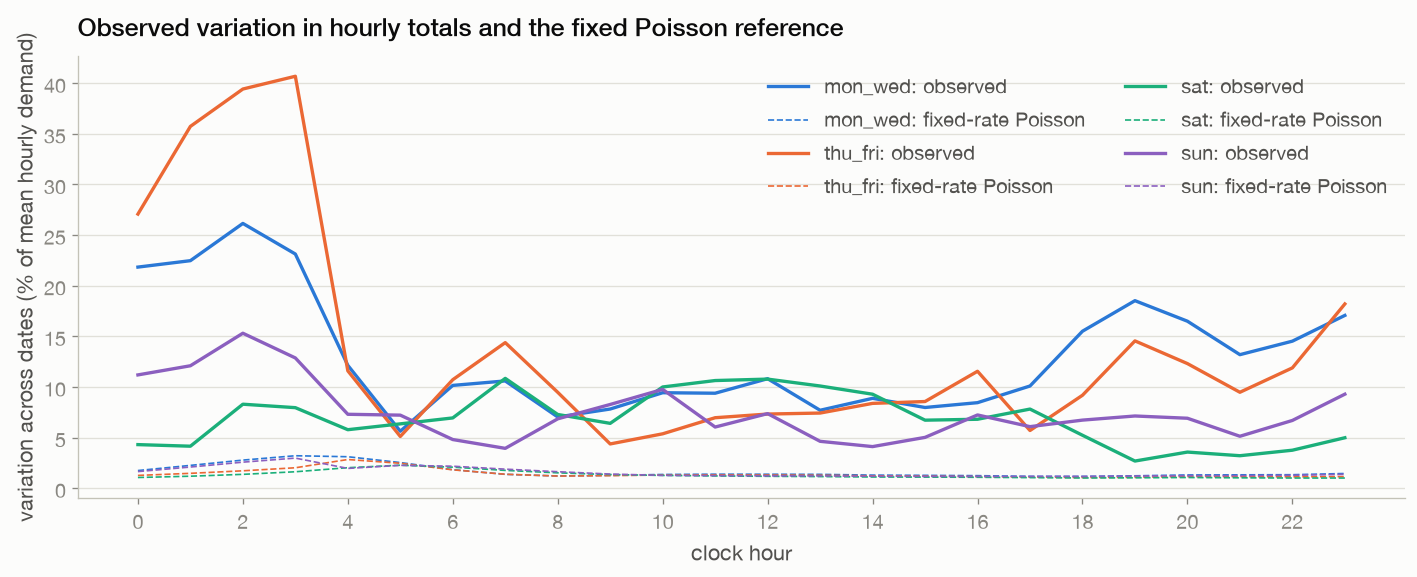

In [15]:
rows = []
for dt, g in FIT_DAYS.groupby("day_type"):
    m = g.requests.mean()
    dow_means = g.groupby("sim_dow").requests.transform("mean")
    within = np.sqrt(((g.requests - dow_means) ** 2).sum() / max(len(g) - g.sim_dow.nunique(), 1))
    rows.append({"day_type": dt, "mean_per_day": round(m), "sd_poisson": round(np.sqrt(m)),
                 "sd_observed": round(g.requests.std()), "sd_within_weekday": round(within),
                 "ratio_observed": round(g.requests.std() / np.sqrt(m), 1),
                 "ratio_within_weekday": round(within / np.sqrt(m), 1)})
LEVEL = pd.DataFrame(rows)

hour_tot = hourly.groupby(["day_type", "h"]).n.agg(["mean", "std"]).reset_index()
hour_tot["cv"] = hour_tot["std"] / hour_tot["mean"]
hour_tot["cv_poisson"] = 1 / np.sqrt(hour_tot["mean"])
fig, ax = plt.subplots(figsize=(12, 5))
for dt in DAY_TYPES:
    g = hour_tot[hour_tot.day_type == dt].sort_values("h")
    ax.plot(g.h, 100 * g.cv, color=colors[dt], lw=2, label=f"{dt}: observed")
    ax.plot(g.h, 100 * g.cv_poisson, color=colors[dt], lw=1, ls="--", label=f"{dt}: fixed-rate Poisson")
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("clock hour"); ax.set_ylabel("variation across dates (% of mean hourly demand)")
ax.set_title("Observed variation in hourly totals and the fixed Poisson reference")
ax.legend(ncol=2)
fig.tight_layout()
display(LEVEL)

thu_fri_hourly = con.sql("""
SELECT sim_dt, sim_dow, h, count(*) AS n
FROM q
WHERE day_type = 'thu_fri'
GROUP BY 1, 2, 3
ORDER BY 1, 2, 3
""").df()
thu_fri_hourly["weekday"] = thu_fri_hourly.sim_dow.map(DOW)

rows = []
for h, g in thu_fri_hourly.groupby("h"):
    pooled_mean = g.n.mean()
    weekday_means = g.groupby("weekday").n.mean()
    residual = g.n - g.groupby("weekday").n.transform("mean")
    within_sd = np.sqrt(
        (residual ** 2).sum() / (len(g) - g.weekday.nunique())
    )
    total_ss = ((g.n - pooled_mean) ** 2).sum()
    between_ss = sum(
        len(group) * (group.n.mean() - pooled_mean) ** 2
        for _, group in g.groupby("weekday")
    )
    rows.append({
        "hour": int(h),
        "thu_mean": round(weekday_means["Thu"]),
        "fri_mean": round(weekday_means["Fri"]),
        "fri_vs_thu_pct": round(100 * (weekday_means["Fri"] / weekday_means["Thu"] - 1), 1),
        "pooled_cv_pct": round(100 * g.n.std(ddof=1) / pooled_mean, 1),
        "within_weekday_cv_pct": round(100 * within_sd / pooled_mean, 1),
        "weekday_variance_share_pct": round(100 * between_ss / total_ss, 1),
    })
THU_FRI_HOURLY = pd.DataFrame(rows).set_index("hour")
THU_FRI_OVERNIGHT = THU_FRI_HOURLY.loc[[22, 23, 0, 1, 2, 3, 4]].reset_index()
print("Thursday and Friday decomposition around midnight")
display(THU_FRI_OVERNIGHT)

split_obs = con.sql("""
SELECT CASE sim_dow WHEN 4 THEN 'thu' WHEN 5 THEN 'fri' END AS weekday,
       mo.z AS zo, md.z AS zd, h, count(*) AS n
FROM q
JOIN mp mo ON q.o = mo.lid
JOIN mp md ON q.d = md.lid
WHERE sim_dow IN (4, 5)
GROUP BY 1, 2, 3, 4
""").df()
split_days = {"thu": int((FIT_DAYS.sim_dow == 4).sum()),
              "fri": int((FIT_DAYS.sim_dow == 5).sum())}
rows = []
for weekday, days_in_fit in split_days.items():
    g = split_obs[split_obs.weekday == weekday]
    cells = N_PLACES * N_PLACES * 24
    empty = cells - len(g)
    under_one = cells - int((g.n >= days_in_fit).sum())
    rows.append({"weekday": weekday, "days": days_in_fit, "cells": cells,
                 "empty": empty, "pct_empty": round(100 * empty / cells, 1),
                 "under_1_per_hour": under_one,
                 "pct_under_1": round(100 * under_one / cells, 1)})
THU_FRI_SPLIT_SUPPORT = pd.DataFrame(rows)
print("Sample support with separate Thursday and Friday fits")
THU_FRI_SPLIT_SUPPORT

---

### Summary

Observed daily standard deviations are **15.8 to 33.5 times** the values implied by fixed Poisson
rates. After removing the mean for each weekday, the ratios remain between **15.8 and 22.4**. The
fixed rate model therefore understates variation across dates even after accounting for the weekdays
combined within each day type.

The residual standard deviation is approximately 3.9 to 6.6 percent of mean daily demand, compared
with approximately 0.25 percent under the fixed Poisson model. These estimates still combine June and
July and contain any remaining seasonal trend. They measure variation over the calibration window;
they do not isolate a stationary random effect for a generic date.

#### Thursday and Friday around midnight

The largest hourly variation has a more specific explanation. A Thursday demand date covers Thursday
at 04:00 through Friday at 03:59. A Friday demand date covers Friday at 04:00 through Saturday at
03:59. The hours from midnight through 03:00 therefore compare early Friday with early Saturday.

Mean demand on the Friday demand date is **67.5 percent higher at 00:00**, **99.2 percent higher at
01:00**, **113.9 percent higher at 02:00**, and **120.9 percent higher at 03:00**. The pooled
coefficient of variation rises from 27.1 to 40.7 percent across these hours. The difference between
the Thursday and Friday means explains approximately **95 to 96 percent** of that variation. After
removing the weekday means, residual variation falls to **5.7 to 9.2 percent**.

The same divergence begins before midnight: Friday demand is 23.2 percent higher at 22:00 and
40.7 percent higher at 23:00. At 04:00, after the demand date boundary, the difference falls to
16.8 percent. The pattern is the expected difference between Thursday night and Friday night, carried
across midnight by the demand date convention.

The `thu_fri` model is a poor representation of either weekday during this period. It overstates
Thursday night demand and understates Friday night demand by averaging the two profiles. This is a
structural limitation of the day type grouping identified in Section 3, rather than evidence of a
40 percent unexplained random fluctuation. The fitted artifact remains unchanged, so evaluations that
include these hours inherit this limitation.

Consider an evening reporting window from 16:00 through 18:00. Friday mean demand exceeds Thursday
mean demand by 4.9 to 6.8 percent during these hours, so the direct averaging error is considerably
smaller than it is overnight. The overnight period is part of the warmup and can still affect vehicle
locations and battery states at the start of reporting. A full day evaluation would include the affected
hours directly. The current pooling is therefore a reasonable provisional approximation for
the evening reporting window, subject to a sensitivity test, but it is a material limitation for
a full day evaluation.

#### Future work

Fitting independent Thursday and Friday tables would reduce the number of dates per estimate from 15
to eight and seven. The share of empty cells would rise from 4.3 percent in the pooled table to
7.1 percent for Thursday and 6.3 percent for Friday. This is a moderate loss of support, while the
weekday hourly totals remain based on thousands of requests.

A revised model can retain shared estimation of origin and destination patterns while fitting
separate Thursday and Friday hourly profiles. Partial pooling or smoothing across adjacent hours and
zones can provide support for rare cells without averaging the distinct late night profiles. The
comparison should include out of sample demand error and the principal experimental KPIs. If the change
alters policy rankings or material KPI estimates, the demand artifact and any affected policy comparison
should be regenerated.

Across the full day, fixed hourly rates also compress variation between dates. A date level random
multiplier remains a possible extension after accounting for weekday and month effects. The present
sample contains only 7 to 24 dates per day type, so that distribution is not fitted here and is absent
from the current demand artifact.

### 5.2 Variation within the hour

For a constant Poisson rate, request times are uniform within each hour. The comparison divides every
hour into four 15 minute intervals and measures the distance between the observed shares and an equal
25 percent allocation. The metric is the minimum percentage of hourly request mass that would need to
move between quarter hours for the distributions to match.

**Columns of the table below.** One row per day type.

| Column | Meaning |
|---|---|
| `day_type` | Demand type |
| `request_weighted_difference` | Quarter hour difference averaged across hours and weighted by request volume |
| `maximum_hour_difference` | Largest quarter hour difference among the 24 hours |
| `hour_of_maximum` | Clock hour with the largest difference |

,day_type,request_weighted_difference,maximum_hour_difference,hour_of_maximum
0,mon_wed,2.25,9.50,6
1,sat,1.97,7.00,6
2,sun,2.15,6.54,9
3,thu_fri,1.87,9.57,6


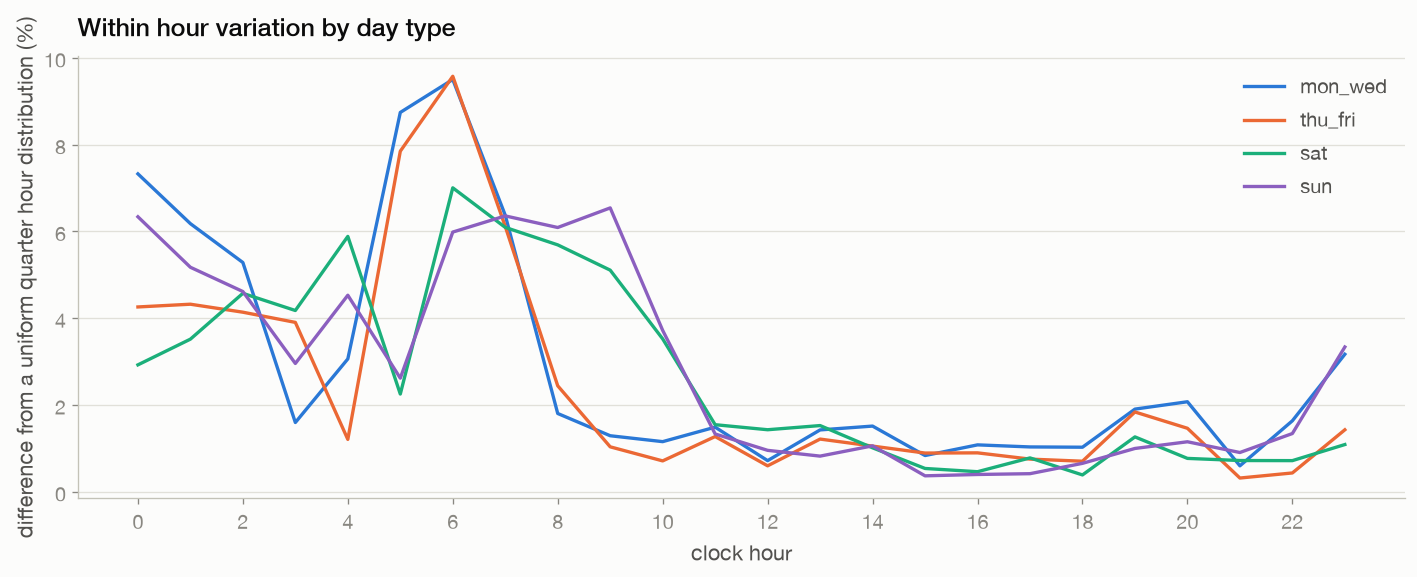

In [16]:
qtr = con.sql("""
SELECT day_type, h, mi // 15 AS quarter, count(*) AS n
FROM q
GROUP BY 1, 2, 3
ORDER BY 1, 2, 3
""").df()
qtr["share"] = qtr.n / qtr.groupby(["day_type", "h"]).n.transform("sum")
qtr["excess"] = (qtr.share - 0.25).clip(lower=0)

within_hour = qtr.groupby(["day_type", "h"]).agg(
    requests=("n", "sum"),
    difference=("excess", "sum"),
).reset_index()
within_hour["difference_pct"] = 100 * within_hour.difference

rows = []
for dt, g in within_hour.groupby("day_type"):
    maximum = g.loc[g.difference_pct.idxmax()]
    rows.append({
        "day_type": dt,
        "request_weighted_difference": round(
            np.average(g.difference_pct, weights=g.requests), 2),
        "maximum_hour_difference": round(maximum.difference_pct, 2),
        "hour_of_maximum": int(maximum.h),
    })
WITHIN_HOUR = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 5))
for dt in DAY_TYPES:
    g = within_hour[within_hour.day_type == dt].sort_values("h")
    ax.plot(g.h, g.difference_pct, color=colors[dt], lw=2, label=dt)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("clock hour")
ax.set_ylabel("difference from a uniform quarter hour distribution (%)")
ax.set_title("Within hour variation by day type")
ax.legend()
fig.tight_layout()
WITHIN_HOUR

---

### Summary

The request weighted difference from a uniform quarter hour distribution ranges from **1.87 to
2.25 percent** across the four day types. The maximum hourly difference ranges from **6.54 to
9.57 percent**. Monday through Wednesday, Thursday and Friday, and Saturday reach their maximum at
06:00; Sunday reaches its maximum at 09:00.

The hourly model represents the daily distribution closely in aggregate, but it smooths the demand
ramp within particular morning hours. This limitation is concentrated rather than uniform across the
day. The current artifact retains hourly resolution; a finer temporal model has not been evaluated.

## 6. Passenger flow imbalance across decision zones

This section measures how completed passenger trips redistribute vehicles among the 20 decision zones.
For each request, its origin is counted as a departure and its destination as an arrival in the hour
when the request was submitted. Assigning both endpoints to the same request cohort ensures that total
arrivals and departures are equal within each hour and isolates spatial imbalance from trip duration.

For each zone and hour, net passenger flow equals destination counts minus origin counts. The hourly
imbalance index sums the origin surplus across zones and divides it by the number of requests in that
hour. Because the system is closed, the origin surplus equals the destination surplus.

The index is calculated for the Monday through Wednesday day type and averaged over its 24 fitted dates.

### Relation to repositioning

A high imbalance indicates that passenger trips move vehicles away from the spatial distribution of
request origins. It identifies periods and locations in which initial placement and repositioning can
matter.

The index is not observed empty travel or a minimum repositioning requirement. Vehicles can be carried
between hours, positioned in advance, or left idle where later demand occurs. The calculation also
assigns destinations to the request hour rather than the physical dropoff hour. Actual availability,
empty movement, distance, and energy depend on travel time, initial inventory, and policy and would be
measured in a policy evaluation.

**Columns of the table below.** One row per request hour for Monday through Wednesday.

| Column | Meaning |
|---|---|
| `h` | Request hour |
| `requests` | Requests submitted in the hour, per fitted date |
| `imbalance` | Sum across zones of origin counts minus destination counts where positive, per fitted date |
| `imbalance_pct` | Imbalance as a percentage of requests submitted in the hour |

passenger flow imbalance at 20 decision zones: 5.9% of requests
passenger flow imbalance at 61 taxi zones: 7.6% of requests


,requests,imbalance,imbalance_pct
h,,,
0,3312.0,400.0,12.1
1,1978.0,213.0,10.8
2,1303.0,129.0,9.9
3,976.0,58.0,6.0
4,1039.0,79.0,7.6
5,1564.0,197.0,12.6
6,3000.0,431.0,14.4
7,5375.0,518.0,9.6
8,6941.0,663.0,9.5


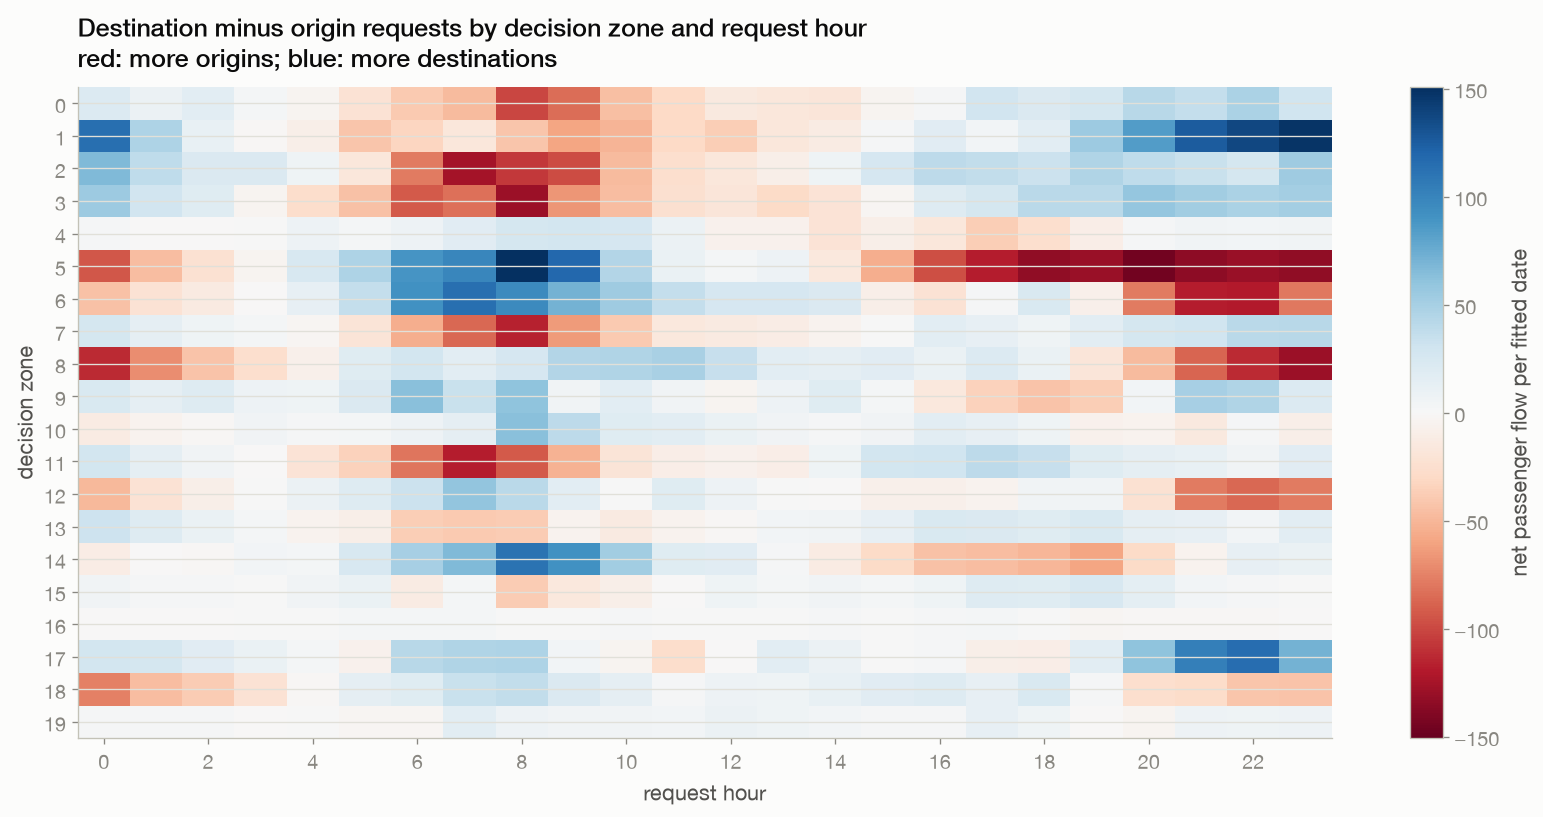

In [17]:
dep = con.sql("""
SELECT mo.z AS place, h, count(*) AS n FROM q JOIN mp mo ON q.o = mo.lid
WHERE day_type = 'mon_wed' GROUP BY 1, 2 ORDER BY 1, 2
""").df()
dest = con.sql("""
SELECT md.z AS place, h, count(*) AS n FROM q JOIN mp md ON q.d = md.lid
WHERE day_type = 'mon_wed' GROUP BY 1, 2 ORDER BY 1, 2
""").df()
flow = (pd.MultiIndex.from_product([range(N_PLACES), range(24)], names=["place", "h"]).to_frame(index=False)
          .merge(dep.rename(columns={"n": "origins"}), how="left")
          .merge(dest.rename(columns={"n": "destinations"}), how="left").fillna(0))
flow[["origins", "destinations"]] /= N_DAYS["mon_wed"]
flow["net"] = flow.destinations - flow.origins
FLOW = flow

by_h = flow.groupby("h").apply(lambda g: pd.Series({
    "requests": g.origins.sum(), "imbalance": (-g.net.clip(upper=0)).sum()}), include_groups=False)
by_h["imbalance_pct"] = (100 * by_h.imbalance / by_h.requests).round(1)

# The same calculation at the 61 taxi-zone resolution quantifies the imbalance hidden by aggregation.
taxi_dep = con.sql("""
SELECT o AS place, h, count(*) AS n FROM q
WHERE day_type = 'mon_wed' GROUP BY 1, 2
""").df()
taxi_dest = con.sql("""
SELECT d AS place, h, count(*) AS n FROM q
WHERE day_type = 'mon_wed' GROUP BY 1, 2
""").df()
taxi_flow = (pd.MultiIndex.from_product([bk_ids, range(24)], names=["place", "h"]).to_frame(index=False)
               .merge(taxi_dep.rename(columns={"n": "origins"}), how="left")
               .merge(taxi_dest.rename(columns={"n": "destinations"}), how="left").fillna(0))
taxi_flow["net"] = taxi_flow.destinations - taxi_flow.origins
taxi_zone_imbalance_pct = 100 * (-taxi_flow.net.clip(upper=0)).sum() / taxi_flow.origins.sum()
decision_zone_imbalance_pct = 100 * by_h.imbalance.sum() / by_h.requests.sum()
print(f"passenger flow imbalance at 20 decision zones: {decision_zone_imbalance_pct:.1f}% of requests")
print(f"passenger flow imbalance at 61 taxi zones: {taxi_zone_imbalance_pct:.1f}% of requests")

fig, ax = plt.subplots(figsize=(14, 7))
M = flow.pivot(index="place", columns="h", values="net")
lim = np.abs(M.values).max()
im = ax.imshow(M.values, aspect="auto", cmap="RdBu", norm=TwoSlopeNorm(0, -lim, lim))
ax.set_yticks(range(N_PLACES)); ax.set_ylabel("decision zone")
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("request hour")
ax.set_title("Destination minus origin requests by decision zone and request hour\n"
             "red: more origins; blue: more destinations")
fig.colorbar(im, ax=ax, label="net passenger flow per fitted date")
fig.tight_layout()
by_h.round(0).astype({"imbalance_pct": float}).assign(imbalance_pct=by_h.imbalance_pct)

---

### Summary

At the 20 decision zone resolution, the passenger flow imbalance index is **5.9 percent** of Monday
through Wednesday requests. Relative imbalance is highest at 06:00, at **14.4 percent** of requests in
that hour. It is also elevated from midnight through 02:00 and again from 20:00 through 23:00. Between
11:00 and 15:00, it ranges from 1.8 to 3.2 percent.

The same requests produce an imbalance index of **7.6 percent** at the original 61 taxi zone
resolution. Aggregating to 20 zones therefore removes 1.7 percentage points, or approximately
23 percent of the imbalance observed at the finer resolution. Movements between taxi zones assigned
to the same decision zone no longer contribute to the index.

The morning pattern shows more origins than destinations in several eastern and southern zones, with
corresponding destination surpluses in central and western Brooklyn. The direction changes for several
zones in the late evening. These passenger flows indicate when spatial positioning is likely to
matter. A policy evaluation would measure the empty movements produced by each policy.

**Columns of the table below.** One row per decision zone for Monday through Wednesday.

| Column | Meaning |
|---|---|
| `place` | Decision zone number |
| `origins` | Requests originating in the zone, per fitted date |
| `destinations` | Requests ending in the zone, per fitted date |
| `net_day` | Destinations minus origins over the demand date |
| `swing` | Range of cumulative net passenger flow when request cohorts are ordered from 04:00 through 03:00 |
| `largest_origin_surplus_hour` | Request hour with the largest excess of origins over destinations |
| `largest_origin_surplus` | Net passenger flow during that hour; negative values indicate more origins |

,place,origins,destinations,net_day,swing,largest_origin_surplus_hour,largest_origin_surplus
0,5,7155,6485,-670,1262,20,-145
1,1,12286,12695,409,760,9,-60
2,8,6904,6595,-309,646,23,-129
3,6,6667,6760,92,570,22,-120
4,17,11562,12117,555,559,11,-27
5,3,6576,6429,-146,556,8,-129
6,2,10116,10085,-32,525,7,-125
7,14,3968,4141,173,432,19,-60
8,7,4119,3929,-190,426,8,-116
9,11,4364,4167,-197,426,7,-119


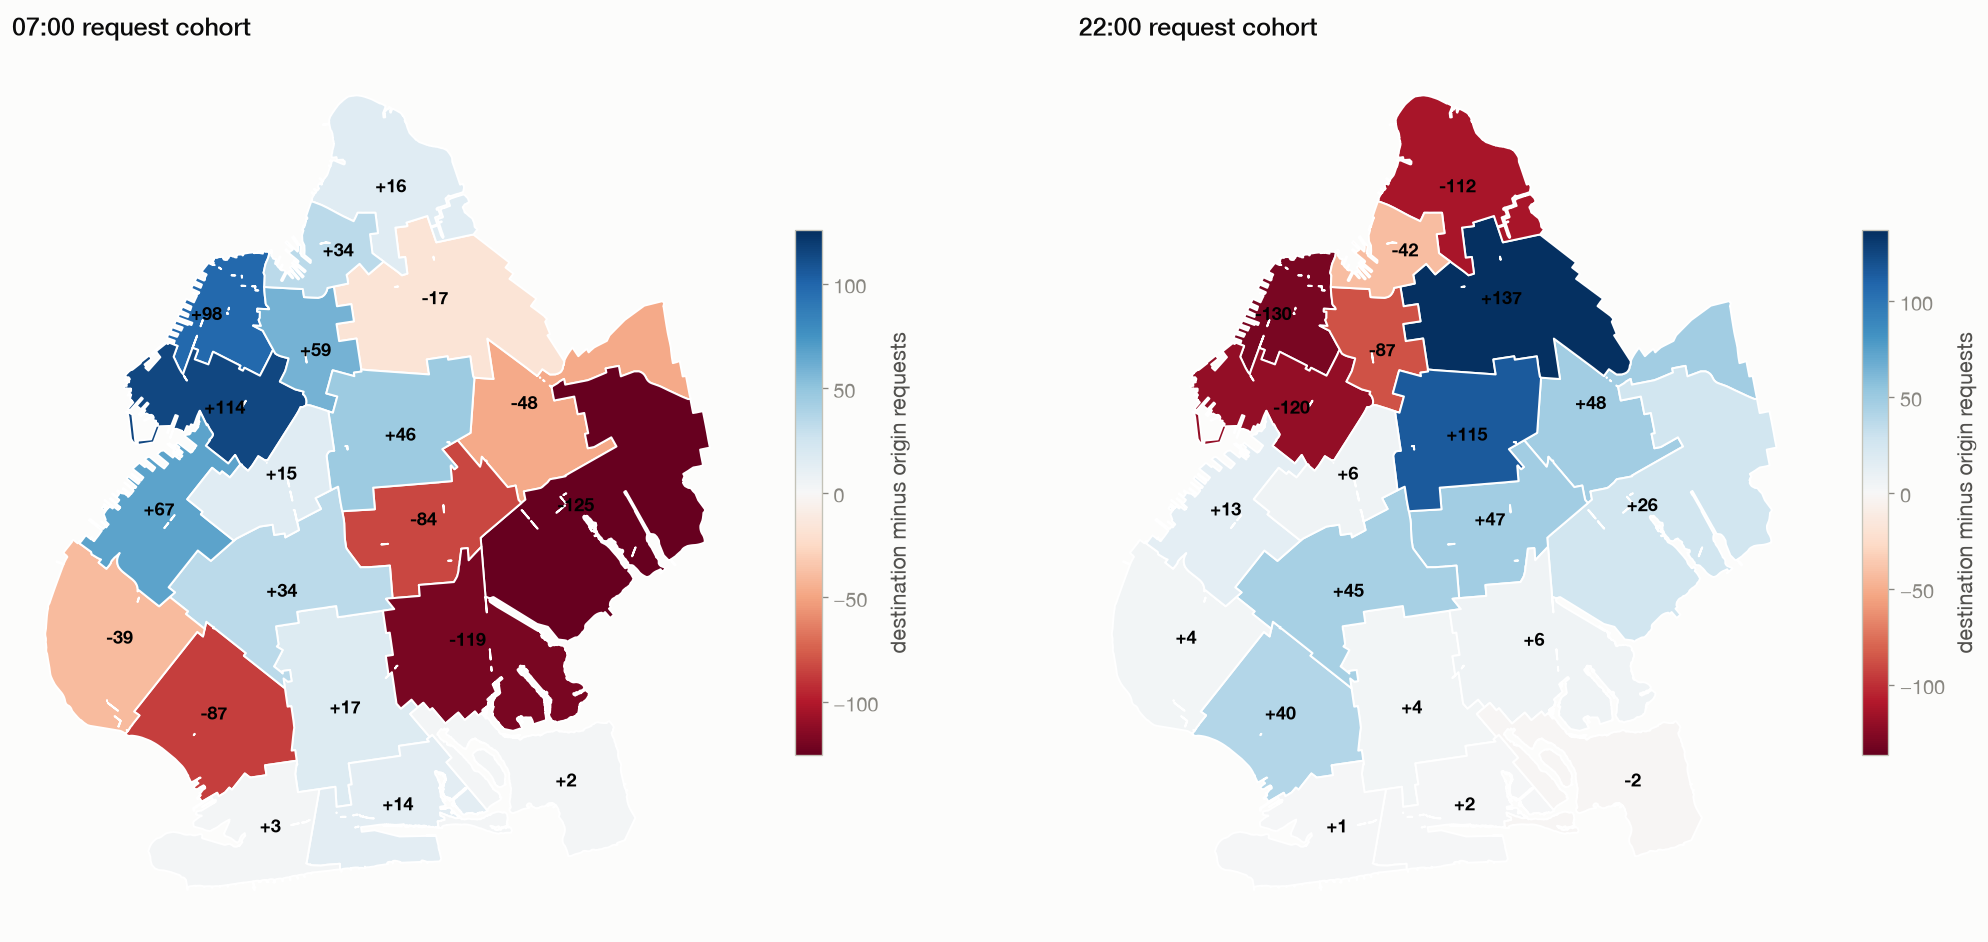

In [18]:
order_h = (flow.h - 4) % 24
flow_s = flow.assign(sim_h=order_h).sort_values(["place", "sim_h"])
rows = []
for p, g in flow_s.groupby("place"):
    cumulative_net = g.net.cumsum()
    largest_origin_surplus = g.loc[g.net.idxmin()]
    rows.append({"place": p,
                 "origins": round(g.origins.sum()),
                 "destinations": round(g.destinations.sum()),
                 "net_day": round(g.net.sum()),
                 "swing": round(cumulative_net.max() - cumulative_net.min()),
                 "largest_origin_surplus_hour": int(largest_origin_surplus.h),
                 "largest_origin_surplus": round(largest_origin_surplus.net)})
PLACES_FLOW = pd.DataFrame(rows).sort_values("swing", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, hh in zip(axes, (7, 22)):
    g = shp.dissolve(by="place")
    g["net"] = flow[flow.h == hh].set_index("place").net
    lim = np.abs(g.net).max()
    g.plot(column="net", ax=ax, cmap="RdBu", norm=TwoSlopeNorm(0, -lim, lim), edgecolor="white",
           linewidth=1.2, legend=True, legend_kwds={"label": "destination minus origin requests", "shrink": 0.6})
    for p, geom in zip(g.index, g.geometry):
        c = geom.representative_point()
        ax.annotate(f"{g.net[p]:+.0f}", (c.x, c.y), ha="center", va="center", fontsize=11, weight="bold")
    ax.set_axis_off(); ax.set_title(f"{hh:02d}:00 request cohort")
fig.tight_layout()
PLACES_FLOW

---

### Summary

Daily net flow varies across decision zones even though it sums to zero across Brooklyn. Zone 5,
which includes Downtown Brooklyn and adjacent neighborhoods, has approximately **670 more origins
than destinations per fitted date**. Zone 17, which includes Crown Heights and Prospect Lefferts
Gardens, has approximately **555 more destinations than origins**.

Zone 5 also has the largest cumulative swing, approximately **1,262 passenger trips** across the
04:00 to 03:00 ordering of request cohorts. The next largest swings are approximately 760 in zone 1
and 646 in zone 8. These values describe the timing and direction of passenger flows. They are not
vehicle requirements because vehicles can enter a period in different locations and trips finish
after their request hour.

### Retained tradeoff

Assigning both endpoints to the request hour makes the imbalance measure spatially balanced within
each hour and directly comparable across zone maps. The resulting index does not represent the clock
time at which a vehicle reaches its destination or becomes available. Travel time and vehicle state
remain part of the operating model and are omitted from this diagnostic.

## 7. Sensitivity to the number of decision zones

Notebook 04 retains 20 contiguous decision zones as a compromise between spatial detail and travel
cell coverage. This section evaluates the corresponding demand model from 16 through 24 zones. Every
candidate is produced by the same contiguous Ward procedure, so the comparison changes the number of
zones without changing the clustering method.

The demand comparison covers four effects:

1. **Rate support.** Finer maps create more origin, destination, and hour cells and fewer observations
   per cell.
2. **Low volume zones.** A zone with little demand provides weak evidence for its temporal and spatial
   rates.
3. **Within zone resolution.** A finer map reduces the share of trips represented on the travel matrix
   diagonal and can reduce variation in demand density within a zone.
4. **Travel coverage.** Finer maps increase the number of duration cells that use a fallback rather
   than a directly estimated distribution.

### Interpretation of the travel coverage measures

Notebook 04 reports two weighting schemes. `borrowed_cells_pct` gives equal weight to every possible
origin, destination, and hour cell. `borrowed_passenger_trips_pct` weights those cells by observed
passenger trips. Neither measure estimates fallback use by repositioning, because that frequency
depends on the movements generated by a policy.

The unweighted measure describes matrix coverage. The passenger weighted measure describes coverage
for observed occupied trips. Both are retained because policy generated movements may differ from the
observed passenger distribution.

**Columns of the table below.** Demand measures use the 24 fitted Monday through Wednesday dates.

| Column | Meaning |
|---|---|
| `zones` | Number of decision zones |
| `smallest_zone` | Mean requests per fitted date originating in the lowest volume zone |
| `zones_under_1000` | Zones with fewer than 1,000 origin requests per fitted date |
| `pct_empty` | Percentage of origin, destination, and hour cells with no observed request |
| `pct_under_1` | Percentage of cells with a fitted rate below one request per hour |
| `median_rate` | Median fitted requests per hour across all cells |
| `same_zone_share` | Share of requests whose endpoints are in the same decision zone |
| `density_ratio_median` | Median across decision zones of the ratio between the highest and lowest taxi zone request densities within each decision zone |
| `density_ratio_max` | Maximum within zone density ratio |
| `borrowed_cells_pct` | Unweighted percentage of travel cells using a fallback, reported in Notebook 04 for 16, 20, and 24 zones |
| `borrowed_passenger_trips_pct` | Percentage of observed passenger trips using those borrowed travel cells |

In [19]:
TRAVEL_BORROWED_CELLS = {16: 2.90, 20: 15.92, 24: 21.81}
TRAVEL_BORROWED_TRIPS = {16: 0.044, 20: 0.210, 24: 0.462}
zone_vol = con.sql("SELECT o AS LocationID, count(*) AS n FROM q WHERE day_type = 'mon_wed' GROUP BY 1").df()
zone_vol = shp[["LocationID", "area_sqmi"]].merge(zone_vol, how="left").fillna({"n": 0})
zone_vol["density"] = zone_vol.n / N_DAYS["mon_wed"] / zone_vol.area_sqmi

rows, LABELS = [], {}
for k in range(16, 25):
    lab = zoning.contiguous_labels(k, shp, adj)
    LABELS[k] = lab
    g = rate_grid(k, lab)
    g = g[g.day_type == "mon_wed"]
    vol = g.groupby("zo").n.sum() / N_DAYS["mon_wed"]
    zv = zone_vol.assign(place=zone_vol.LocationID.map(lab))
    ratio = zv.groupby("place").density.agg(lambda s: s.max() / max(s.min(), 1e-9))
    rows.append({"zones": k,
                 "smallest_zone": round(vol.min()),
                 "zones_under_1000": int((vol < 1000).sum()),
                 "pct_empty": round(100 * (g.n == 0).mean(), 1),
                 "pct_under_1": round(100 * (g.rate < 1).mean(), 1),
                 "median_rate": round(g.rate.median(), 2),
                 "same_zone_share": round(g[g.zo == g.zd].n.sum() / g.n.sum(), 3),
                 "density_ratio_median": round(ratio.median(), 2),
                 "density_ratio_max": round(ratio.max(), 1),
                 "borrowed_cells_pct": TRAVEL_BORROWED_CELLS.get(k, np.nan),
                 "borrowed_passenger_trips_pct": TRAVEL_BORROWED_TRIPS.get(k, np.nan)})
publish(ZONING)
COUNTS = pd.DataFrame(rows)
COUNTS

,zones,smallest_zone,zones_under_1000,pct_empty,pct_under_1,median_rate,same_zone_share,density_ratio_median,density_ratio_max,borrowed_cells_pct,borrowed_passenger_trips_pct
0,16,2452,0,0.1,14.4,5.04,0.351,1.91,109.0,2.90,0.044
1,17,48,1,4.0,24.1,3.88,0.351,1.78,109.0,NaN,NaN
2,18,48,1,3.8,23.2,3.75,0.329,1.73,109.0,NaN,NaN
3,19,48,1,4.1,26.4,3.25,0.315,1.78,109.0,NaN,NaN
4,20,48,2,4.2,29.2,2.79,0.313,1.73,57.6,15.92,0.210
5,21,48,2,4.7,33.2,2.38,0.310,1.49,57.6,NaN,NaN
6,22,48,2,4.5,34.7,2.12,0.301,1.48,57.6,NaN,NaN
7,23,48,2,4.5,35.4,2.04,0.287,1.46,57.6,NaN,NaN
8,24,48,2,4.5,37.6,1.83,0.281,1.41,57.6,21.81,0.462


---

### Summary

The 16 zone map has the strongest demand support. Its lowest volume zone has approximately 2,452
origin requests per fitted date, 0.1 percent of demand cells are empty, and 14.4 percent have rates
below one request per hour. At 17 zones, the clustering separates Marine Park and Floyd Bennett Field
into a zone with approximately 48 daily requests. Empty cells increase to 4.0 percent. From 20 zones
onward, two zones have fewer than 1,000 daily requests.

Additional zones improve spatial resolution. The same zone trip share declines from 35.1 percent at
16 zones to 31.3 percent at 20 and 28.1 percent at 24. Median within zone density variation declines
from a ratio of 1.91 to 1.73 and 1.41. The maximum remains high at every count because several merged
zones combine residential areas with parks or other very low demand land uses.

Travel coverage shows the same support tradeoff. The unweighted share of travel cells using a fallback
is 2.90 percent at 16 zones, 15.92 percent at 20, and 21.81 percent at 24. These cells contain only
0.044, 0.210, and 0.462 percent of observed passenger trips. The large change in unweighted coverage
is therefore concentrated in rare passenger movements. Repositioning policies may use a different
set of cells, so their fallback frequency cannot be inferred from the passenger weights.

| Candidate | Statistical support | Spatial detail | Retained limitation |
|---|---|---|---|
| 16 zones | Highest demand and travel cell support; no zone below 1,000 daily requests | Highest same zone share and greatest compression of travel and energy variation | Coarser location and movement representation |
| 20 zones | Intermediate support; observed passenger trips rarely use borrowed travel cells | Lower same zone share and finer representation of northern Brooklyn | One 48 request zone, a second zone below 1,000 requests, and 15.92 percent unweighted travel fallback |
| 24 zones | Lowest support among the three evaluated travel maps | Lowest same zone share and least compression of the evaluated candidates | More sparse demand cells and 21.81 percent unweighted travel fallback |

The evidence does not identify a unique optimum. Sixteen zones are preferable for estimation support,
while 20 retain more spatial detail. The current artifact remains at 20 zones so that demand and travel
use the same implemented map and completed runs remain comparable. The low volume zones and
fallback exposure are retained consequences of that choice.

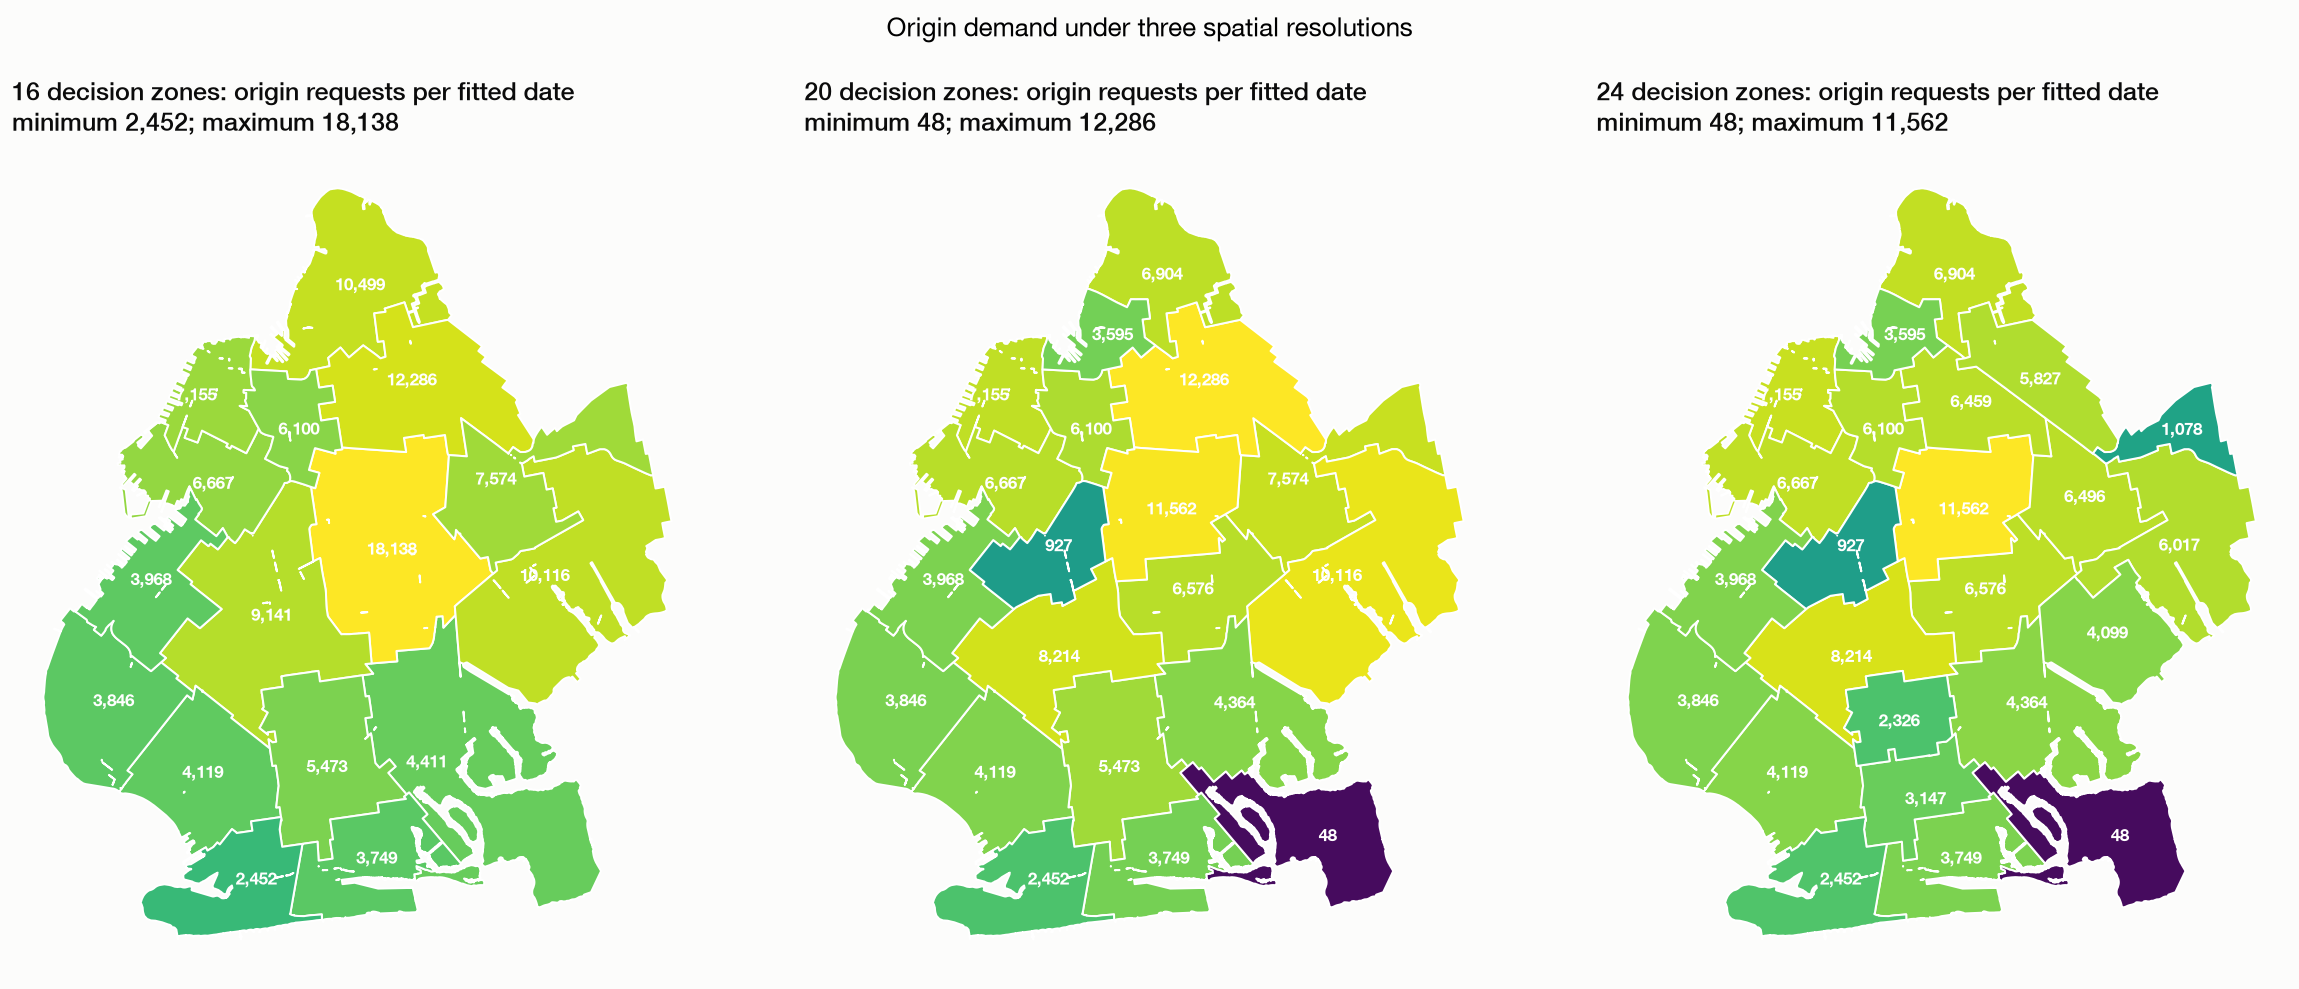

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, k in zip(axes, (16, 20, 24)):
    g = shp.copy()
    g["place"] = g.LocationID.map(LABELS[k])
    d = g.dissolve(by="place")
    vol = zone_vol.assign(place=zone_vol.LocationID.map(LABELS[k])).groupby("place").n.sum() / N_DAYS["mon_wed"]
    d["requests_per_day"] = vol
    d.plot(column="requests_per_day", ax=ax, cmap="viridis", norm=LogNorm(vmin=40, vmax=vol.max()),
           edgecolor="white", linewidth=1.2)
    for p, geom in zip(d.index, d.geometry):
        c = geom.representative_point()
        ax.annotate(f"{vol[p]:,.0f}", (c.x, c.y), ha="center", va="center", fontsize=10,
                    color="white", weight="bold")
    ax.set_axis_off()
    ax.set_title(f"{k} decision zones: origin requests per fitted date\n"
                 f"minimum {vol.min():,.0f}; maximum {vol.max():,.0f}")
fig.suptitle("Origin demand under three spatial resolutions", y=1.03)
fig.tight_layout()

---

### Map comparison

At 16 zones, southeastern Brooklyn remains one unit with approximately 2,452 origin requests per
fitted date. At 20 and 24 zones, Marine Park and Floyd Bennett Field form a separate zone with only
48 requests. The additional boundaries primarily divide higher volume areas in northern and central
Brooklyn.

The maps show the source of the tradeoff. Finer zoning adds detail where demand is concentrated, while
the same clustering sequence also isolates a low demand area. The current 20 zone map retains both
effects.

### Retained tradeoff

Twenty zones preserve more spatial detail than 16 and remain consistent with the fitted travel
artifact. In exchange, the demand table contains more sparse cells and one zone with very little
observed demand. A policy weighted comparison of fallback use and experimental KPIs is required to
determine whether the added spatial detail improves operational results.

## 8. Stability of fitted demand rates across calibration subsets

Each demand rate is estimated as the mean count across the fitted dates of its day type: 24 for
`mon_wed`, 15 for `thu_fri`, seven for `sat`, and eight for `sun`. This section measures how much the
estimated cell rates change when the calibration dates are divided into two interleaved subsets.

Dates are assigned alternately within each weekday. This preserves weekday composition as closely as
the available counts permit and distributes earlier and later dates across both subsets. A separate
rate table is estimated from each half. For each cell observed in at least one half, the comparison
uses the absolute difference between the two rates divided by their mean.

A fixed rate Poisson reference is generated using the same cell rate and the actual number of dates in
each half. The reference measures variation expected from independent Poisson counts. Differences
above it can arise from variation across dates, month effects, or residual weekday heterogeneity.

### Scope of the diagnostic

The split is descriptive rather than a confidence interval. It evaluates one balanced partition of the
calibration dates and does not measure every possible subset. Saturday is divided into four and three
dates, while Sunday is divided into four and four. Their results therefore have less support than the
12 date halves for Monday through Wednesday.

Cells with no requests in either half are excluded because their relative difference is undefined.
Low rate cells can show large percentage differences from only a few observations, so the table also
reports the share of total requests represented by each rate band.

**Columns of the table below.** Cells are grouped by their fitted rate over both halves.

| Column | Meaning |
|---|---|
| `rate_band` | Fitted requests per hour for the origin, destination, and hour cell |
| `cells` | Cells observed in at least one half |
| `request_share` | Share of fitted requests represented by the band |
| `observed_median` | Median relative difference between the two fitted half sample rates |
| `observed_p90` | 90th percentile of the relative difference |
| `poisson_median` | Median relative difference in the fixed rate Poisson reference |
| `poisson_p90` | 90th percentile in the fixed rate Poisson reference |

dates per half: {'mon_wed/0': 12, 'mon_wed/1': 12, 'sat/0': 4, 'sat/1': 3, 'sun/0': 4, 'sun/1': 4, 'thu_fri/0': 8, 'thu_fri/1': 7}


mon_wed: median hourly difference 4.3%; maximum 14.1% at 18:00
thu_fri: median hourly difference 6.3%; maximum 11.8% at 16:00
sat: median hourly difference 1.4%; maximum 8.2% at 06:00
sun: median hourly difference 3.1%; maximum 7.7% at 02:00


,rate_band,cells,request_share,observed_median,observed_p90,poisson_median,poisson_p90
0,under 0.5,4640,0.002,1.000,2.000,0.667,2.000
1,0.5 to 2,8404,0.019,0.370,1.000,0.364,1.000
2,2 to 5,7386,0.044,0.222,0.590,0.218,0.588
3,5 to 20,8624,0.162,0.138,0.382,0.126,0.343
4,over 20,7419,0.773,0.081,0.209,0.056,0.160


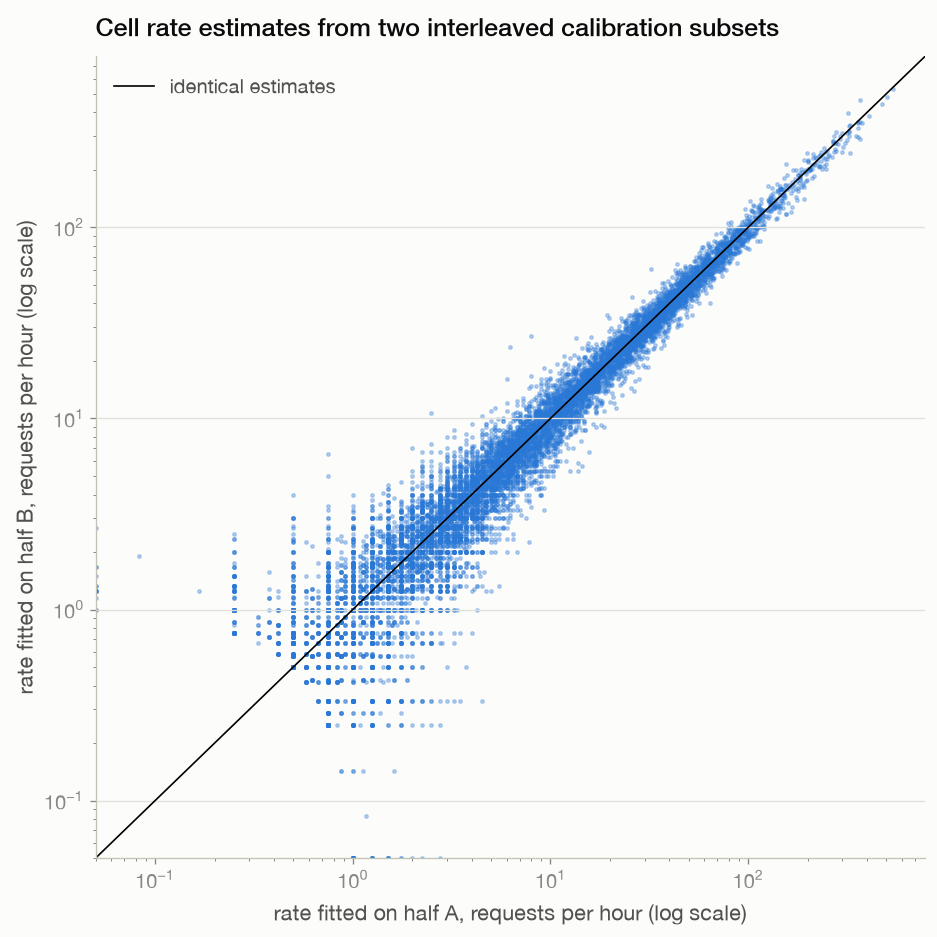

In [21]:
halves = FIT_DAYS.sort_values("sim_day").copy()
halves["half"] = halves.groupby("sim_dow").cumcount() % 2
halves = halves.rename(columns={"sim_day": "sim_dt"})[["sim_dt", "day_type", "half"]]
n_half = halves.groupby(["day_type", "half"]).size()
print("dates per half:", {f"{d}/{h}": int(n) for (d, h), n in n_half.items()})

ph = per_day.merge(halves, on=["sim_dt", "day_type"])
sh = ph.groupby(["day_type", "zo", "zd", "h", "half"]).n.sum().unstack("half").fillna(0).reset_index()
sh["nA"] = sh.day_type.map(lambda d: n_half[(d, 0)])
sh["nB"] = sh.day_type.map(lambda d: n_half[(d, 1)])
sh["rA"] = sh[0] / sh.nA
sh["rB"] = sh[1] / sh.nB
sh["pooled_rate"] = (sh[0] + sh[1]) / (sh.nA + sh.nB)
sh["relative_difference"] = (sh.rA - sh.rB).abs() / ((sh.rA + sh.rB) / 2)
sh["rate_band"] = pd.cut(sh.pooled_rate, [0, 0.5, 2, 5, 20, 1e9],
                          labels=["under 0.5", "0.5 to 2", "2 to 5", "5 to 20", "over 20"])

rng = np.random.default_rng(SEED)
rows = []
for rate_band, g in sh.groupby("rate_band", observed=True):
    a = rng.poisson(g.pooled_rate.values * g.nA.values) / g.nA.values
    b = rng.poisson(g.pooled_rate.values * g.nB.values) / g.nB.values
    simulated_difference = np.abs(a - b) / np.where(a + b > 0, (a + b) / 2, 1)
    rows.append({"rate_band": rate_band,
                 "cells": len(g),
                 "request_share": round(g.pooled_rate.sum() / sh.pooled_rate.sum(), 3),
                 "observed_median": round(g.relative_difference.median(), 3),
                 "observed_p90": round(g.relative_difference.quantile(0.9), 3),
                 "poisson_median": round(np.median(simulated_difference), 3),
                 "poisson_p90": round(np.quantile(simulated_difference, 0.9), 3)})
STAB = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 8))
eligible = sh[sh.pooled_rate >= 0.5]
s = eligible.sample(min(12000, len(eligible)), random_state=SEED)
display_floor = 0.05
ax.scatter(s.rA.clip(lower=display_floor), s.rB.clip(lower=display_floor), s=4, alpha=0.3)
lim = (display_floor, sh[["rA", "rB"]].max().max() * 1.2)
ax.plot(lim, lim, "k-", lw=1, label="identical estimates")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("rate fitted on half A, requests per hour (log scale)")
ax.set_ylabel("rate fitted on half B, requests per hour (log scale)")
ax.set_title("Cell rate estimates from two interleaved calibration subsets")
ax.legend()
fig.tight_layout()

hour_halves = ph.groupby(["day_type", "h", "half"]).n.sum().unstack("half")
for day_type in DAY_TYPES:
    a = hour_halves.loc[day_type][0] / n_half[(day_type, 0)]
    b = hour_halves.loc[day_type][1] / n_half[(day_type, 1)]
    relative_difference = (a - b).abs() / ((a + b) / 2)
    print(f"{day_type}: median hourly difference {100 * relative_difference.median():.1f}%; "
          f"maximum {100 * relative_difference.max():.1f}% at {int(relative_difference.idxmax()):02d}:00")
STAB

---

### Summary

Cells with fitted rates above 20 requests per hour represent **77.3 percent** of fitted demand. Their
rates differ between the two calibration subsets by a median of **8.1 percent** and a 90th percentile
of **20.9 percent**. The fixed rate Poisson reference gives 5.6 and 16.0 percent. The excess indicates
that independent Poisson sampling does not explain all instability among high volume cells.

For cells below five requests per hour, the observed and Poisson differences are similar. Cells below
two requests per hour account for 2.1 percent of fitted demand and frequently differ by 100 percent or
more because each half contains few observations. Their aggregate volume is small, although their
locations and timing can still affect individual modeled movements.

Median differences in aggregate hourly demand range from 1.4 percent for Saturday to 6.3 percent for
Thursday and Friday. Maximum hourly differences range from 7.7 to 14.1 percent across the four day
types. The largest median difference, for `thu_fri`, is consistent with the heterogeneity identified in
Sections 3 and 5, but this single split does not attribute the difference to weekday pooling. Month effects and
residual variation across dates also remain possible.

### Retained tradeoff

Using all fitted dates for the final table maximizes cell support and averages variation across the
calibration window. The resulting rates are estimates of mean demand. They do not represent
uncertainty in rare cells or correlated changes across a date. The split half comparison quantifies
sensitivity to one partition; it does not provide confidence intervals for the fitted rates.

## 9. Capture share and approximate fleet load

Capture share, `alpha`, is a configurable experiment parameter. It scales every fitted demand rate by
the same proportion and determines how much of the observed Brooklyn market is offered to the modeled
fleet. The fitted artifact does not estimate `alpha`.

This section translates candidate capture shares into an approximate passenger service load for fleets
of 100 and 150 vehicles. The calculation uses the peak Monday through Wednesday request rate and a
mean service interval of 19.3 minutes: 4.5 minutes from request to pickup and 14.8 minutes from pickup
to dropoff.

The request to pickup interval is used as an approximation of vehicle commitment time. The records do
not identify when a vehicle was assigned, so part of this interval may have elapsed before assignment.
The calculation also excludes repositioning, charging, and other time out of service. It is therefore
a load screen rather than a prediction of service performance.

### Calculation

For a candidate capture share, the peak request rate is multiplied by the mean service interval and
divided by 60 minutes and the fleet size. The result is an approximate steady state share of the fleet
committed to passenger service. A value above one means that the offered passenger workload exceeds
the fleet size under the stated assumptions.

The 70 percent line is included as an illustrative planning reference. It is not a fitted utilization
target or a model constraint.

**Columns of the first table below.** Monday through Wednesday demand under alternative capture shares.

| Column | Meaning |
|---|---|
| `capture_share_pct` | Configured percentage of observed demand offered to the fleet |
| `requests_per_day` | Mean requests offered per fitted date |
| `peak_requests_per_hour` | Requests offered during the 18:00 peak hour |
| `trips_per_vehicle_day_100` | Offered daily requests divided by 100 vehicles |
| `estimated_peak_load_100` | Approximate passenger service load for 100 vehicles |
| `estimated_peak_load_150` | Approximate passenger service load for 150 vehicles |
| `passenger_km_per_vehicle_day_100` | Occupied passenger distance divided by 100 vehicles |

The second table reports the capture share corresponding to the illustrative 70 percent reference and
to a passenger service load of one under the same approximation.

mean occupied trip: 14.8 minutes
mean request to pickup: 4.5 minutes
approximate service interval: 19.3 minutes
peak market rate: 7,432 requests per hour at 18:00


,capture_share_pct,requests_per_day,peak_requests_per_hour,trips_per_vehicle_day_100,estimated_peak_load_100,estimated_peak_load_150,passenger_km_per_vehicle_day_100
0,1,1157,74,11.6,0.24,0.16,49
1,2,2314,149,23.1,0.48,0.32,97
2,3,3471,223,34.7,0.72,0.48,146
3,4,4628,297,46.3,0.96,0.64,194
4,5,5785,372,57.8,1.20,0.80,243
5,6,6942,446,69.4,1.43,0.96,292
6,8,9256,595,92.6,1.91,1.28,389
7,10,11569,743,115.7,2.39,1.59,486


,fleet_size,capture_share_at_70pct_load,capture_share_at_full_passenger_load
0,100,2.93,4.18
1,150,4.39,6.27


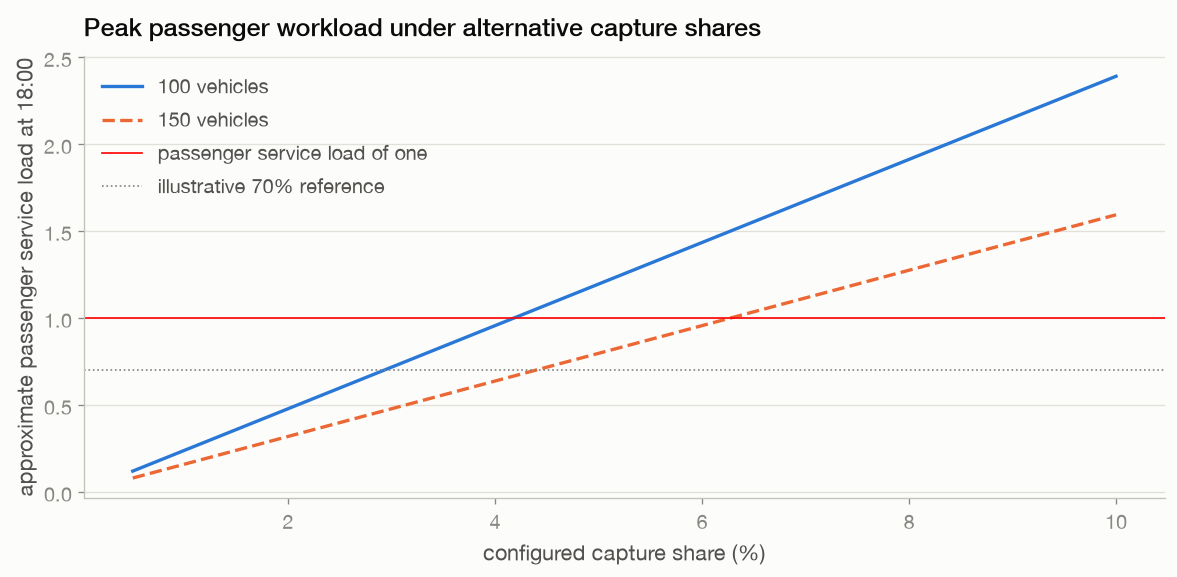

In [22]:
mw_prof = con.sql("SELECT h, count(*) / %d AS n FROM q WHERE day_type = 'mon_wed' GROUP BY 1 ORDER BY 1"
                  % N_DAYS["mon_wed"]).df().set_index("h").n
per_day_mw = FIT_DAYS[FIT_DAYS.day_type == "mon_wed"].requests.mean()
trip_min, request_to_pickup_min, trip_mi = con.sql("""
SELECT avg(trip_time) / 60, avg(date_diff('second', rq, pk)) / 60, avg(trip_miles)
FROM q WHERE day_type = 'mon_wed'""").fetchone()
service_min = trip_min + request_to_pickup_min
peak_hour = int(mw_prof.idxmax())
peak_market_rate = float(mw_prof.max())
print(f"mean occupied trip: {trip_min:.1f} minutes")
print(f"mean request to pickup: {request_to_pickup_min:.1f} minutes")
print(f"approximate service interval: {service_min:.1f} minutes")
print(f"peak market rate: {peak_market_rate:,.0f} requests per hour at {peak_hour:02d}:00")

rows = []
for capture_share in (1, 2, 3, 4, 5, 6, 8, 10):
    requests_per_day = per_day_mw * capture_share / 100
    peak_requests = peak_market_rate * capture_share / 100
    rows.append({"capture_share_pct": capture_share,
                 "requests_per_day": round(requests_per_day),
                 "peak_requests_per_hour": round(peak_requests),
                 "trips_per_vehicle_day_100": round(requests_per_day / 100, 1),
                 "estimated_peak_load_100": round(peak_requests * service_min / 60 / 100, 2),
                 "estimated_peak_load_150": round(peak_requests * service_min / 60 / 150, 2),
                 "passenger_km_per_vehicle_day_100": round(requests_per_day / 100 * trip_mi * 1.609)})
ALPHA = pd.DataFrame(rows)

threshold_rows = []
for fleet_size in (100, 150):
    load_per_capture_point = peak_market_rate * 0.01 * service_min / 60 / fleet_size
    threshold_rows.append({"fleet_size": fleet_size,
                           "capture_share_at_70pct_load": round(0.70 / load_per_capture_point, 2),
                           "capture_share_at_full_passenger_load": round(1.00 / load_per_capture_point, 2)})
LOAD_THRESHOLDS = pd.DataFrame(threshold_rows)

fig, ax = plt.subplots(figsize=(10, 5))
capture_shares = np.linspace(0.5, 10, 100)
for fleet_size, line_style in ((100, "-"), (150, "--")):
    load = peak_market_rate * capture_shares / 100 * service_min / 60 / fleet_size
    ax.plot(capture_shares, load, line_style, lw=2, label=f"{fleet_size} vehicles")
ax.axhline(1.0, color="red", lw=1, label="passenger service load of one")
ax.axhline(0.7, color="grey", lw=1, ls=":", label="illustrative 70% reference")
ax.set_xlabel("configured capture share (%)")
ax.set_ylabel(f"approximate passenger service load at {peak_hour:02d}:00")
ax.set_title("Peak passenger workload under alternative capture shares")
ax.legend()
fig.tight_layout()
display(ALPHA)
LOAD_THRESHOLDS

---

### Summary

At a 5 percent capture share, the approximate peak passenger service load is **1.20** for 100 vehicles
and **0.80** for 150 vehicles. Under this screening calculation, the offered passenger workload alone
exceeds a 100 vehicle fleet during the 18:00 peak. A 5 percent scenario is therefore a deliberate
capacity constrained case for that fleet size, rather than a fixed model setting.

For 100 vehicles, the corresponding loads are 0.72 at 3 percent and 0.96 at 4 percent. For 150
vehicles, they are 0.48 and 0.64. The illustrative 70 percent reference corresponds to capture shares
of approximately 2.9 percent for 100 vehicles and 4.4 percent for 150. A passenger service load of one
corresponds to approximately 4.2 and 6.3 percent.

These values do not include charging, repositioning, or other unavailable time. They also assume that
the observed request to pickup interval represents vehicle commitment and that the mean service
interval applies during the peak. A policy evaluation would be required to measure realized service, queueing,
charging, and rider outcomes.

### Retained tradeoffs

Uniform scaling preserves the fitted spatial and temporal demand distribution and makes fleet load
comparable across scenarios. It assumes that the captured share does not vary by location or hour.
Absolute service outcomes and policy behavior near capacity remain sensitive to the configured value.

The analytic load screen is transparent and useful for scenario selection, but it compresses the
service time distribution into one mean and omits competing vehicle activities. It should be read as
an approximation of offered workload rather than a capacity estimate.

## 10. Evaluation against August 2025

The demand table is fitted on June and July and evaluated on the 30 complete demand dates from August
1 through August 30. August is excluded from fitting. October remains unexamined in this notebook and
is reserved for later system validation.

The evaluation reports five aspects of predictive performance:

1. **Daily level:** mean requests per date.
2. **Hourly shape:** the distribution of requests across the 24 clock hours.
3. **Spatial marginals:** the origin and destination distributions across 20 decision zones.
4. **Joint shape:** the origin, destination, and hour distribution represented by the complete demand
   table.
5. **Unobserved cells:** August demand in cells assigned a fitted rate of zero.

Shape error is measured with total variation distance. A value of 5 percent means that 5 percent of
probability mass would have to be reassigned for the fitted and August distributions to match.
Normalizing the shapes separates their distribution from the difference in total demand.

Capture share can be configured to recalibrate the offered demand level. A common scaling does not
make level error irrelevant: absolute congestion and service outcomes depend on load, and nonlinear
capacity effects can alter policy comparisons.

### Evaluation status and date screening

August is now an evaluation sample rather than an untouched holdout. If its results are used to revise
the fitted model, a later month is required for an independent assessment of that revision.

The leave one out table below describes variation within August. It is a diagnostic screen rather than
an automatic exclusion rule. No independently identified disruption period is removed from August,
and all 30 complete demand dates are retained.

**Columns of the table below.** The six August dates with the largest percentage differences from
their weekday references.

| Column | Meaning |
|---|---|
| `sim_day` | Demand date assigned using the 04:00 boundary |
| `weekday` | Weekday of the demand date |
| `requests` | Brooklyn to Brooklyn completed trip requests |
| `pct_vs_baseline` | Percentage difference from the mean of the other August dates with the same weekday |
| `z` | Difference divided by the standard deviation of those other dates |

In [23]:
con_aug = session(TEST_MONTH)                 # separate connection: August is excluded from fitting
build_pu(con_aug)
build_q(con_aug, "2025-08-01", "2025-08-30", [])   # same request and demand-date definitions as the fit

aug_days = con_aug.sql("""
SELECT sim_dt AS sim_day, sim_dow, count(*) AS requests FROM q GROUP BY 1, 2 ORDER BY 1
""").df()
aug_days["sim_day"] = pd.to_datetime(aug_days.sim_day)
aug_days["weekday"] = aug_days.sim_dow.map(DOW)
aug_days["day_type"] = np.select(
    [aug_days.sim_dow.isin([1, 2, 3]), aug_days.sim_dow.isin([4, 5]), aug_days.sim_dow == 6],
    ["mon_wed", "thu_fri", "sat"], "sun")

rows = []
for dow, g in aug_days.groupby("sim_dow"):
    for _, r in g.iterrows():
        others = g[g.sim_day != r.sim_day].requests
        if len(others) < 3:
            continue
        rows.append({"sim_day": r.sim_day.date(), "weekday": r.weekday, "requests": r.requests,
                     "pct_vs_baseline": round(100 * (r.requests / others.mean() - 1), 1),
                     "z": round((r.requests - others.mean()) / others.std(ddof=1), 2)})
AUG_LOO = pd.DataFrame(rows)
beyond = AUG_LOO.loc[AUG_LOO.pct_vs_baseline.abs() > 15, "sim_day"].tolist()
print(f"August days by type: {aug_days.groupby('day_type').size().to_dict()}")
print(f"August dates more than 15% from their weekday reference: {beyond if beyond else 'none'}")
AUG_LOO.reindex(AUG_LOO.pct_vs_baseline.abs().sort_values(ascending=False).index).head(6)

August days by type: {'mon_wed': 12, 'sat': 5, 'sun': 4, 'thu_fri': 9}
August dates more than 15% from their weekday reference: none


,sim_day,weekday,requests,pct_vs_baseline,z
14,2025-08-20,Wed,133782,14.6,2.12
15,2025-08-27,Wed,109346,-12.4,-1.69
2,2025-08-17,Sun,120663,6.7,2.06
3,2025-08-24,Sun,109736,-6.0,-1.73
12,2025-08-06,Wed,115458,-6.0,-0.59
23,2025-08-22,Fri,140898,-5.6,-3.31


---

### August date coverage

The largest leave one out difference is 14.6 percent on August 20. No date differs from its weekday
reference by more than 15 percent. All 30 complete August demand dates are included in the evaluation.
The screen does not establish that August contains no events; it records that no date is removed after
inspection of this diagnostic.

**Columns of the level table.** One row per day type.

| Column | Meaning |
|---|---|
| `day_type` | Fitted day type |
| `fit_days` | June and July dates used for fitting |
| `aug_days` | Complete August dates used for evaluation |
| `fitted_per_day` | Mean completed trip requests predicted per date |
| `august_per_day` | Mean completed trip requests observed per August date |
| `level_error_pct` | Fitted level relative to the August level |

**Columns of the shape table.** All values are total variation distances in percentage points.

| Column | Meaning |
|---|---|
| `hours_pct` | Error in the 24 hour marginal distribution |
| `origins_pct` | Error in the 20 zone origin marginal distribution |
| `destinations_pct` | Error in the 20 zone destination marginal distribution |
| `od_pct` | Error in the joint origin and destination distribution |
| `joint_odh_pct` | Error in the complete origin, destination, and hour distribution |
| `joint_sampling_median_pct` | Median joint error from 200 multinomial samples drawn from the fitted shape with the August sample size |
| `joint_sampling_p90_pct` | 90th percentile of the same sampling reference |

,day_type,fit_days,aug_days,fitted_per_day,august_per_day,level_error_pct
0,mon_wed,24,12,115694,108847,6.3
1,thu_fri,15,9,144593,136380,6.0
2,sat,7,5,166267,154483,7.6
3,sun,8,4,122469,114997,6.5


,day_type,hours_pct,origins_pct,destinations_pct,od_pct,joint_odh_pct,joint_sampling_median_pct,joint_sampling_p90_pct
0,mon_wed,0.82,1.03,1.06,1.64,4.28,2.45,2.49
1,thu_fri,1.66,1.74,1.64,2.45,4.99,2.56,2.59
2,sat,1.25,2.88,2.70,4.40,6.87,3.23,3.27
3,sun,1.01,2.37,2.22,4.04,7.33,4.16,4.21


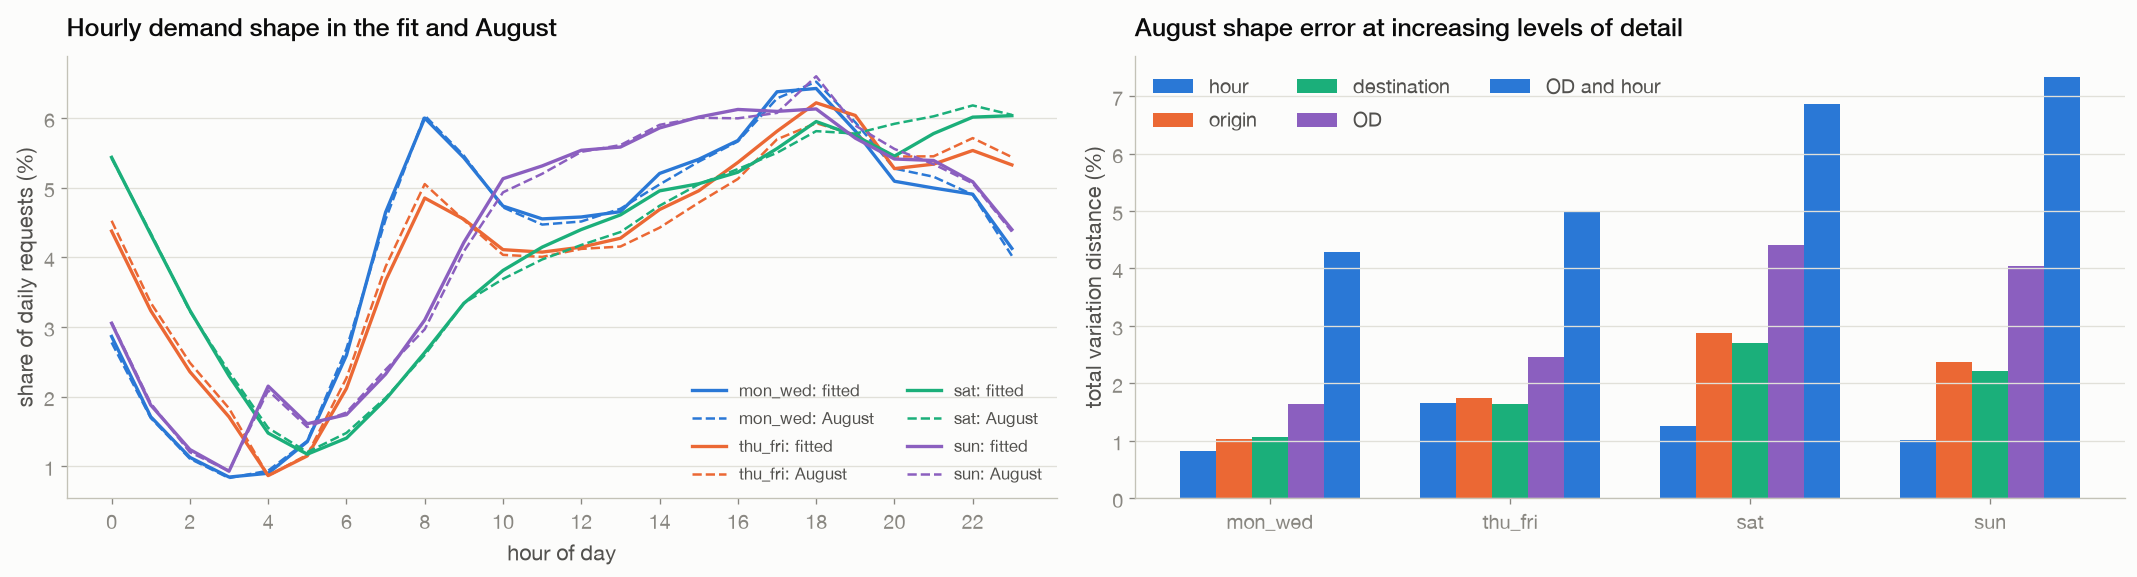

In [24]:
fit_trip = con.sql("""
SELECT day_type, o, d, h, count(*) AS n
FROM q GROUP BY 1, 2, 3, 4
""").df()
aug_trip = con_aug.sql("""
SELECT day_type, o, d, h, count(*) AS n
FROM q GROUP BY 1, 2, 3, 4
""").df()
for frame in (fit_trip, aug_trip):
    frame["zo"] = frame.o.map(ZONING)
    frame["zd"] = frame.d.map(ZONING)

fit_joint = fit_trip.groupby(["day_type", "zo", "zd", "h"], as_index=False).n.sum()
aug_joint = aug_trip.groupby(["day_type", "zo", "zd", "h"], as_index=False).n.sum()


def total_variation(fitted, observed, dimensions):
    keys = ["day_type", *dimensions]
    fit_counts = fitted.groupby(keys, as_index=False).n.sum()
    obs_counts = observed.groupby(keys, as_index=False).n.sum()
    joined_shape = fit_counts.merge(obs_counts, on=keys, how="outer", suffixes=("_fit", "_aug")).fillna(0)
    joined_shape["p_fit"] = joined_shape.n_fit / joined_shape.groupby("day_type").n_fit.transform("sum")
    joined_shape["p_aug"] = joined_shape.n_aug / joined_shape.groupby("day_type").n_aug.transform("sum")
    joined_shape["absolute_difference"] = (joined_shape.p_fit - joined_shape.p_aug).abs()
    return 50 * joined_shape.groupby("day_type").absolute_difference.sum()


tv_hours = total_variation(fit_joint, aug_joint, ["h"])
tv_origins = total_variation(fit_joint, aug_joint, ["zo"])
tv_destinations = total_variation(fit_joint, aug_joint, ["zd"])
tv_od = total_variation(fit_joint, aug_joint, ["zo", "zd"])
tv_joint = total_variation(fit_joint, aug_joint, ["zo", "zd", "h"])

fit_tot = fit_joint.groupby("day_type").n.sum() / pd.Series(N_DAYS)
aug_nd = aug_days.groupby("day_type").size()
aug_tot = aug_joint.groupby("day_type").n.sum() / aug_nd
LEVEL_SCORE = pd.DataFrame({
    "day_type": DAY_TYPES,
    "fit_days": [N_DAYS[d] for d in DAY_TYPES],
    "aug_days": [int(aug_nd[d]) for d in DAY_TYPES],
    "fitted_per_day": [round(fit_tot[d]) for d in DAY_TYPES],
    "august_per_day": [round(aug_tot[d]) for d in DAY_TYPES],
})
LEVEL_SCORE["level_error_pct"] = (
    100 * (LEVEL_SCORE.fitted_per_day / LEVEL_SCORE.august_per_day - 1)
).round(1)

joint_grid = pd.MultiIndex.from_product(
    [range(N_PLACES), range(N_PLACES), range(24)], names=["zo", "zd", "h"]
).to_frame(index=False)
rng = np.random.default_rng(SEED)
sampling_reference = {}
for day_type in DAY_TYPES:
    fitted = joint_grid.merge(
        fit_joint[fit_joint.day_type == day_type].drop(columns="day_type"),
        on=["zo", "zd", "h"], how="left"
    ).fillna({"n": 0})
    observed = joint_grid.merge(
        aug_joint[aug_joint.day_type == day_type].drop(columns="day_type"),
        on=["zo", "zd", "h"], how="left"
    ).fillna({"n": 0})
    fitted_probability = fitted.n.to_numpy() / fitted.n.sum()
    august_count = int(observed.n.sum())
    simulated_tv = []
    for _ in range(200):
        simulated_probability = rng.multinomial(august_count, fitted_probability) / august_count
        simulated_tv.append(50 * np.abs(simulated_probability - fitted_probability).sum())
    sampling_reference[day_type] = (
        float(np.median(simulated_tv)), float(np.quantile(simulated_tv, 0.9))
    )

SHAPE_SCORE = pd.DataFrame({
    "day_type": DAY_TYPES,
    "hours_pct": [round(tv_hours[d], 2) for d in DAY_TYPES],
    "origins_pct": [round(tv_origins[d], 2) for d in DAY_TYPES],
    "destinations_pct": [round(tv_destinations[d], 2) for d in DAY_TYPES],
    "od_pct": [round(tv_od[d], 2) for d in DAY_TYPES],
    "joint_odh_pct": [round(tv_joint[d], 2) for d in DAY_TYPES],
    "joint_sampling_median_pct": [round(sampling_reference[d][0], 2) for d in DAY_TYPES],
    "joint_sampling_p90_pct": [round(sampling_reference[d][1], 2) for d in DAY_TYPES],
})
SCORE = LEVEL_SCORE.merge(SHAPE_SCORE, on="day_type")

fit_hour_share = (fit_joint.groupby(["day_type", "h"]).n.sum().unstack("h").fillna(0))
aug_hour_share = (aug_joint.groupby(["day_type", "h"]).n.sum().unstack("h").fillna(0))
fit_hour_share = fit_hour_share.div(fit_hour_share.sum(axis=1), axis=0)
aug_hour_share = aug_hour_share.div(aug_hour_share.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for day_type in DAY_TYPES:
    axes[0].plot(range(24), 100 * fit_hour_share.loc[day_type], color=colors[day_type],
                 lw=2, label=f"{day_type}: fitted")
    axes[0].plot(range(24), 100 * aug_hour_share.loc[day_type], color=colors[day_type],
                 lw=1.5, ls="--", label=f"{day_type}: August")
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_xlabel("hour of day")
axes[0].set_ylabel("share of daily requests (%)")
axes[0].set_title("Hourly demand shape in the fit and August")
axes[0].legend(ncol=2, fontsize=10)

metrics = [("hours_pct", "hour"), ("origins_pct", "origin"),
           ("destinations_pct", "destination"), ("od_pct", "OD"),
           ("joint_odh_pct", "OD and hour")]
x = np.arange(len(DAY_TYPES))
width = 0.15
for index, (column, label) in enumerate(metrics):
    axes[1].bar(x + (index - 2) * width, SHAPE_SCORE[column], width, label=label)
axes[1].set_xticks(x)
axes[1].set_xticklabels(DAY_TYPES)
axes[1].set_ylabel("total variation distance (%)")
axes[1].set_title("August shape error at increasing levels of detail")
axes[1].legend(ncol=3)
fig.tight_layout()
display(LEVEL_SCORE)
SHAPE_SCORE

---

### Summary

The fitted daily level exceeds August for every day type, with errors from **6.0 to 7.6 percent**.
This is consistent with the decline from June to July reported in Section 2.2, followed by a further
decline in August. A revised capture share can rescale offered demand for an August scenario, but the
error remains material when a previously configured capture share is held fixed.

Marginal shapes transfer more closely than the total level. Hourly error ranges from **0.82 to 1.66
percent**. Origin error ranges from **1.03 to 2.88 percent**, and destination error from **1.06 to 2.70
percent**. The joint origin and destination error is higher, from **1.64 to 4.40 percent**.

The complete origin, destination, and hour error ranges from **4.28 percent** for Monday through
Wednesday to **7.33 percent** for Sunday. Finite sample variation contributes to this result: the
median multinomial reference ranges from 2.45 to 4.16 percent. The observed joint error exceeds the
90th percentile of that reference for every day type, leaving an excess of approximately 1.8 to 3.6
percentage points beyond the random sampling component.

The results support transfer of the broad hourly and spatial marginals into August. They provide
weaker support for the complete cell distribution, particularly for Saturday and Sunday, which have
the fewest fitting and evaluation dates. Marginal accuracy should therefore not be presented as full
validation of the joint demand table.

### Retained tradeoff

Pooling June and July improves cell support but produces a fitted level above August and averages
changes in the joint distribution across the summer. These are retained limitations of the two month
window. If this August evaluation informs a revised demand model, that revision requires a new
out of sample evaluation rather than reuse of August as independent evidence.

### 10.1 August demand in cells assigned a zero rate

Section 4.1 applies the rule of three to each unobserved cell and sums the individual limits as a
conservative sensitivity calculation. The sum is not a joint confidence bound. August provides a
direct measurement of completed trip requests that occur in cells assigned a zero rate by the June
and July fit.

**Columns of the table below.**

| Column | Meaning |
|---|---|
| `day_type` | Fitted day type |
| `fit_empty_cells` | Cells assigned a zero fitted rate |
| `aug_requests_there` | Mean August requests per date in those cells |
| `pct_of_august` | Requests in those cells as a percentage of August demand |
| `section_4_sensitivity_pct` | Sum of the individual rule of three limits from Section 4.1, as a percentage of fitted daily demand |

,day_type,fit_empty_cells,aug_requests_there,pct_of_august,section_4_sensitivity_pct
0,mon_wed,404,10.8,0.010,0.044
1,thu_fri,409,16.6,0.012,0.057
2,sat,512,53.8,0.035,0.132
3,sun,602,51.8,0.045,0.184


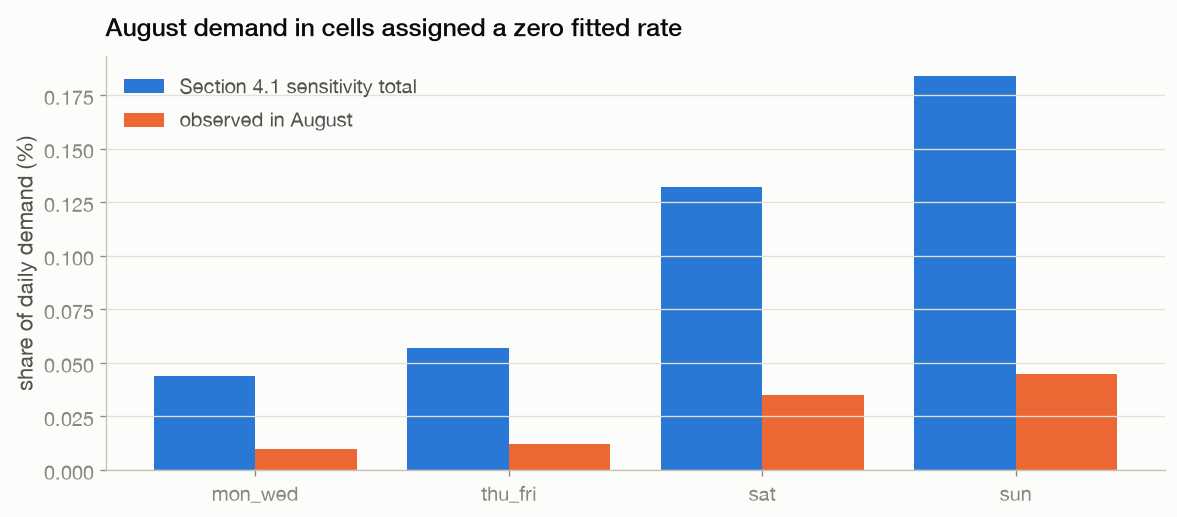

In [25]:
aug_grid = aug_joint.copy()
aug_grid["aug_rate"] = aug_grid.n / aug_grid.day_type.map(aug_nd)

joined = (GRID[["day_type", "zo", "zd", "h", "n"]].rename(columns={"n": "fit_n"})
          .merge(aug_grid[["day_type", "zo", "zd", "h", "aug_rate"]],
                 on=["day_type", "zo", "zd", "h"], how="left")
          .fillna({"aug_rate": 0.0}))

rows = []
for day_type in DAY_TYPES:
    g = joined[joined.day_type == day_type]
    empty = g[g.fit_n == 0]
    rows.append({"day_type": day_type,
                 "fit_empty_cells": len(empty),
                 "aug_requests_there": round(empty.aug_rate.sum(), 1),
                 "pct_of_august": round(100 * empty.aug_rate.sum() / aug_tot[day_type], 3),
                 "section_4_sensitivity_pct": round(
                     100 * len(empty) * (3 / N_DAYS[day_type]) /
                     (g.fit_n.sum() / N_DAYS[day_type]), 3)})
EMPTY = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(DAY_TYPES))
ax.bar(x - 0.2, EMPTY.section_4_sensitivity_pct, 0.4,
       label="Section 4.1 sensitivity total")
ax.bar(x + 0.2, EMPTY.pct_of_august, 0.4,
       label="observed in August")
ax.set_xticks(x)
ax.set_xticklabels(EMPTY.day_type)
ax.set_ylabel("share of daily demand (%)")
ax.set_title("August demand in cells assigned a zero fitted rate")
ax.legend()
fig.tight_layout()
EMPTY

---

### Summary

Cells assigned a zero rate contain **0.010 to 0.045 percent** of August demand, or approximately 11 to
54 requests per date depending on the day type. The observed shares are below the Section 4.1
sensitivity totals for every day type.

This result supports the conclusion that zero rate cells have little effect on aggregate August demand.
It does not establish that a zero rate is the best predictor for every rare cell. A smoothed model
could improve probability estimates or spatial coverage even when the aggregate volume is small.
Evaluation of smoothing would require a predictive score and a new evaluation sample if August informs
the choice.

### Retained tradeoff

Assigning zero avoids introducing unobserved spatial and temporal patterns. It omits rare combinations
that appear in a later month. The aggregate omission is small in August, while the operational effect
can be larger if a policy depends on one of the affected locations or routes.

## 11. Retained modeling tradeoffs

The fitted demand artifact retains the choices below. The final column records the limitation created
by each choice and identifies the results most likely to be affected.

| Choice | Reason retained | Consequence |
|---|---|---|
| Treat completed trips as observed demand | Request time, origin, and destination are available consistently for completed trips. | Rejected, canceled, abandoned, and otherwise unserved requests are absent. The fitted rates may reflect supply constraints and do not estimate latent demand. |
| Restrict demand to trips wholly within Brooklyn | The demand and travel artifacts then describe the same closed service region. | The fit excludes 24.63 percent of trips that begin in Brooklyn and end elsewhere, as well as trips entering Brooklyn. Cross boundary distance, energy use, and vehicle redistribution are absent. |
| Assign midnight through 03:59 to the preceding demand date | The convention keeps late night demand with the preceding operating evening and does not constrain when an evaluation period begins. | The interpretation of weekday labels differs from calendar dates. It also makes the difference between Thursday night and Friday night especially visible within the pooled `thu_fri` type. |
| Exclude the heat and Independence Day periods from baseline demand | The baseline is not averaged with two identified disruptions. | Six dates are removed from estimation, and their behavior must be represented through separate scenarios. |
| Pool June and July | Two months reduce empty cells by 27 to 42 percent relative to June alone and improve support for weekend rates. | The window remains limited to summer. August daily demand is 6.0 to 7.6 percent below the fitted level, and the complete origin, destination, and hour shape differs by 4.28 to 7.33 percent. |
| Use four day types | Pooling provides more observations for each spatial and hourly cell while separating Saturday and Sunday. | Saturday and Sunday rates rely on seven and eight dates. Thursday and Friday remain pooled despite a large late night difference. The pooled profile overstates Thursday night and understates Friday night. |
| Retain 20 decision zones | The demand model remains aligned with the travel matrix and preserves more spatial detail than a 16 zone alternative. | A low volume area around Marine Park and Floyd Bennett Field becomes a separate zone, and finer zoning increases sparse cells. Sixteen zones provide stronger demand support but less positioning detail. |
| Assign zero to an unobserved cell | The artifact does not invent demand patterns without observations, and August shows that these cells contain a very small share of requests. | Rare origin, destination, and hour combinations are understated. A policy can still generate vehicle movements through locations where passenger demand is nearly absent. |
| Use fixed hourly Poisson arrivals | The model is transparent, compact, and reproducible from the fitted rate table. | Fixed rate Poisson dates are much more similar than observed dates. Heavy demand days and correlated changes across cells are underrepresented. |
| Hold the rate constant within each hour | Hourly cells provide substantially more support than a finer time grid. | The model smooths demand ramps within the hour. The request weighted difference is 1.87 to 2.25 percent by day type and reaches 6.54 to 9.57 percent in the most affected hour. |
| Assign both trip endpoints to the request hour in the passenger flow diagnostic | Using one request cohort isolates spatial origin and destination imbalance and permits comparison across zone maps. | The diagnostic does not represent actual dropoff time, vehicle availability, or required empty repositioning. |
| Configure capture share as a scenario input | A common scale permits experiments with different fleet loads without interpreting provider vehicle totals as simultaneous capacity. | Capture share is not an estimated market share. Absolute service levels and policy behavior near capacity depend on the configured value. |

The Thursday and Friday pooling has limited direct effect on a 16:00 through 18:00 reporting
window, where their mean demand differs by 4.9 to 6.8 percent. The overnight difference occurs during
warmup and can still affect the vehicle distribution and battery state entering that window. A full day
evaluation would include the affected hours directly.

The first temporal revision should retain pooled spatial estimation while fitting separate Thursday
and Friday hourly profiles. This preserves support for rare origin and destination cells while removing
the systematic late night averaging. A date level multiplier can then represent residual variation
across dates. Both changes require comparison on out of sample demand error and on the principal
experimental KPIs before the fitted artifact is revised.